<a href="https://colab.research.google.com/github/Ayseatci/DI725_Assignment1/blob/dev/notebooks/Hybrid_RoBERTa_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone -b dev https://github.com/Ayseatci/DI725_Assignment1.git

Cloning into 'DI725_Assignment1'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 142 (delta 77), reused 70 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (142/142), 1.22 MiB | 6.11 MiB/s, done.
Resolving deltas: 100% (77/77), done.


In [2]:
%cd DI725_Assignment1

/content/DI725_Assignment1


In [3]:
!pip install wandb
!wandb login
import wandb

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ayseatci00 (ayseatci00-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Oversampling and categorical features

In [4]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer
)

# Initialize W&B
PROJECT_NAME = "DI725_Assignment_1"
EXPERIMENT_NAME = "hybrid-roberta-tail-mult4-categorical"

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Global seed set to: {seed}")

set_seed(SEED)

wandb.init(
    project=PROJECT_NAME,
    name=EXPERIMENT_NAME,
    config={
        "learning_rate": 2e-5,
        "epochs": 5,
        "batch_size": 8,
        "oversampling": "4x_minority",
        "model_type": "hybrid_roberta_categorical",
        "truncation": "tail",
        "seed": SEED
    }
)

# Data Loading
train_df = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df = pd.read_csv("data/preprocessed/preprocessed_val.csv")

def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels", "issue_area", "issue_category"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label", "issue_area", "issue_category"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

train_df = normalize_label_column(train_df)
val_df = normalize_label_column(val_df)

train_df["labels"] = train_df["labels"].astype(int)
val_df["labels"] = val_df["labels"].astype(int)

# 4x Oversampling
counts = train_df["labels"].value_counts()
min_class = counts.idxmin()
min_size = counts.min()
max_size = counts.max()

minority_df = train_df[train_df["labels"] == min_class]
target_size = min(min_size * 4, max_size)

upsampled_minority = minority_df.sample(
    n=target_size,
    replace=True,
    random_state=SEED
)

train_df = pd.concat(
    [train_df[train_df["labels"] != min_class], upsampled_minority],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Training label distribution after oversampling:")
print(train_df["labels"].value_counts())

# Encode categorical features
cat_cols = ["issue_area", "issue_category"]
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = train_df[col].astype(str)
    val_df[col] = val_df[col].astype(str)

    le.fit(train_df[col])

    known_classes = set(le.classes_)
    val_df[col] = val_df[col].apply(lambda x: x if x in known_classes else "__UNK__")

    if "__UNK__" not in known_classes:
        le.classes_ = np.append(le.classes_, "__UNK__")

    train_df[col] = le.transform(train_df[col])
    val_df[col] = le.transform(val_df[col])

    encoders[col] = le

cat_dims = [(int(train_df[col].nunique()), 16) for col in cat_cols]

# Hybrid model
class RobertaHybridClassifier(nn.Module):
    def __init__(self, model_name, num_labels, cat_dims):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings, emb_dim)
            for num_embeddings, emb_dim in cat_dims
        ])

        combined_size = self.roberta.config.hidden_size + sum(emb_dim for _, emb_dim in cat_dims)

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, input_ids, attention_mask, categorical_inputs, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]  # CLS/BOS representation

        cat_outputs = []
        for i, emb_layer in enumerate(self.embeddings):
            cat_outputs.append(emb_layer(categorical_inputs[:, i].long()))

        cat_combined = torch.cat(cat_outputs, dim=1)
        final_input = torch.cat((text_output, cat_combined), dim=1)
        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

# Tokenization
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

def tokenize_hybrid(examples):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    cat_data = [
        [area, category]
        for area, category in zip(examples["issue_area"], examples["issue_category"])
    ]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "categorical_inputs": cat_data
    }

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True)).map(tokenize_hybrid, batched=True)
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True)).map(tokenize_hybrid, batched=True)

keep_cols = ["input_ids", "attention_mask", "labels", "categorical_inputs"]
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in keep_cols])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in keep_cols])


class HybridDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        batch["categorical_inputs"] = torch.tensor(
            [f["categorical_inputs"] for f in features],
            dtype=torch.long
        )
        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch


# Trainer
class HybridTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            categorical_inputs=inputs["categorical_inputs"],
            labels=inputs["labels"]
        )
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

# Training setup
model = RobertaHybridClassifier(
    model_name="roberta-base",
    num_labels=3,
    cat_dims=cat_dims
)
model.roberta.resize_token_embeddings(len(tokenizer))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./hybrid_roberta_tail_mult4_categorical",
    seed=SEED,
    data_seed=SEED,
    full_determinism=True,
    dataloader_num_workers=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    logging_first_step=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="wandb",
    remove_unused_columns=False,
    fp16=torch.cuda.is_available()
)

trainer = HybridTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=HybridDataCollator(tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()

# Final Evaluation
print("\n--- Hybrid Model Final Report ---")
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
print(
    classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    )
)

wandb.finish()

Global seed set to: 42


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: ayseatci00 (ayseatci00-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training label distribution after oversampling:
labels
1    433
0    326
2     56
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.490543,0.471953,0.835052,0.555556
2,0.342306,0.307350,0.891753,0.597403
3,0.214679,0.518158,0.809278,0.562023
4,0.179347,0.428994,0.896907,0.603571
5,0.015810,0.457355,0.891753,0.599916



--- Hybrid Model Final Report ---


              precision    recall  f1-score   support

    negative       0.92      0.88      0.90        82
     neutral       0.89      0.94      0.91       109
    positive       0.00      0.00      0.00         3

    accuracy                           0.90       194
   macro avg       0.60      0.60      0.60       194
weighted avg       0.89      0.90      0.89       194



eval/accuracy,▃█▁██
eval/f1_macro,▁▇▂█▇
eval/loss,▆▁█▅▆
eval/runtime,▁▂▃▁█
eval/samples_per_second,█▇▆█▁
eval/steps_per_second,█▇▆█▁
test/accuracy,▁
test/f1_macro,▁
test/loss,▁
test/runtime,▁
+7,...


Oversampling with weighted cross entropy and categorical features

In [5]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer
)

SEED = 42
PROJECT_NAME = "DI725_Assignment_1"

set_seed(SEED)

# Data Loading
train_df_base = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df_base = pd.read_csv("data/preprocessed/preprocessed_val.csv")

def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels", "issue_area", "issue_category"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label", "issue_area", "issue_category"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

train_df_base = normalize_label_column(train_df_base)
val_df_base = normalize_label_column(val_df_base)

train_df_base["labels"] = train_df_base["labels"].astype(int)
val_df_base["labels"] = val_df_base["labels"].astype(int)

# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

# Hybrid model
class RobertaHybridClassifier(nn.Module):
    def __init__(self, model_name, num_labels, cat_dims):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings, emb_dim)
            for num_embeddings, emb_dim in cat_dims
        ])

        combined_size = self.roberta.config.hidden_size + sum(emb_dim for _, emb_dim in cat_dims)

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, input_ids, attention_mask, categorical_inputs, labels=None, loss_weights=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]

        cat_outputs = [
            emb(categorical_inputs[:, i].long())
            for i, emb in enumerate(self.embeddings)
        ]
        cat_combined = torch.cat(cat_outputs, dim=1)

        final_input = torch.cat((text_output, cat_combined), dim=1)
        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            if loss_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

# Tokenization
def tokenize_hybrid(examples, cat_cols):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    cat_data = []
    for row_idx in range(len(examples["text"])):
        cat_data.append([examples[col][row_idx] for col in cat_cols])

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "categorical_inputs": cat_data
    }

# Collator
class HybridDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        batch["categorical_inputs"] = torch.tensor(
            [f["categorical_inputs"] for f in features],
            dtype=torch.long
        )
        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

# Trainer
class HybridTrainer(Trainer):
    def __init__(self, loss_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.loss_weights = loss_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = self.loss_weights.to(model.device) if self.loss_weights is not None else None

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            categorical_inputs=inputs["categorical_inputs"],
            labels=inputs["labels"],
            loss_weights=weights
        )

        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Experiment categorical sets
categorical_feature_sets = [
    ["issue_area", "issue_category"]
]

all_results = []

for cat_cols in categorical_feature_sets:
    set_seed(SEED)
    torch.cuda.empty_cache()

    cat_tag = "_".join(cat_cols)
    experiment_name = f"hybrid-roberta-tail-mult4-categorical-weighted-{cat_tag}"

    print("\n" + "=" * 80)
    print(f"Running experiment: {experiment_name}")
    print(f"Categorical features: {cat_cols}")
    print("=" * 80)

    wandb.init(
        project=PROJECT_NAME,
        name=experiment_name,
        reinit=True,
        config={
            "learning_rate": 2e-5,
            "epochs": 5,
            "batch_size": 8,
            "oversampling": "4x_minority",
            "loss": "weighted_cross_entropy",
            "model_type": "hybrid_roberta_categorical",
            "truncation": "tail",
            "seed": SEED,
            "categorical_features": cat_cols
        }
    )

    train_df = train_df_base.copy()
    val_df = val_df_base.copy()

    original_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_df["labels"]),
        y=train_df["labels"]
    )
    original_weights_tensor = torch.tensor(original_weights, dtype=torch.float)
    print(f"Original Class Weights: {original_weights}")

    # 4x oversampling of smallest class
    counts = train_df["labels"].value_counts()
    min_class = counts.idxmin()
    min_size = counts.min()
    max_size = counts.max()

    minority_df = train_df[train_df["labels"] == min_class]
    target_size = min(min_size * 4, max_size)

    upsampled_minority = minority_df.sample(
        n=target_size,
        replace=True,
        random_state=SEED
    )

    train_df = pd.concat(
        [train_df[train_df["labels"] != min_class], upsampled_minority],
        axis=0
    ).sample(frac=1, random_state=SEED).reset_index(drop=True)

    print("Post-Oversample Distribution:")
    print(train_df["labels"].value_counts())

    # Encode selected categorical columns
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        train_df[col] = train_df[col].astype(str)
        val_df[col] = val_df[col].astype(str)

        le.fit(train_df[col])

        known_classes = set(le.classes_)
        val_df[col] = val_df[col].apply(lambda x: x if x in known_classes else "__UNK__")

        if "__UNK__" not in known_classes:
            le.classes_ = np.append(le.classes_, "__UNK__")

        train_df[col] = le.transform(train_df[col])
        val_df[col] = le.transform(val_df[col])

        encoders[col] = le

    cat_dims = [(int(train_df[col].nunique()), 16) for col in cat_cols]

    # Dataset creation
    train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True)).map(
        lambda examples: tokenize_hybrid(examples, cat_cols),
        batched=True
    )
    val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True)).map(
        lambda examples: tokenize_hybrid(examples, cat_cols),
        batched=True
    )

    keep_cols = ["input_ids", "attention_mask", "labels", "categorical_inputs"]
    train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in keep_cols])
    val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in keep_cols])

    # Model
    model = RobertaHybridClassifier("roberta-base", num_labels=3, cat_dims=cat_dims)
    model.roberta.resize_token_embeddings(len(tokenizer))

    training_args = TrainingArguments(
        output_dir=f"./hybrid_weighted_results_categorical_{cat_tag}",
        seed=SEED,
        data_seed=SEED,
        full_determinism=True,
        dataloader_num_workers=0,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=10,
        logging_first_step=True,
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="wandb",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    )

    trainer = HybridTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=HybridDataCollator(tokenizer),
        compute_metrics=compute_metrics,
        loss_weights=original_weights_tensor
    )

    # Execute
    trainer.train()

    preds_output = trainer.predict(val_dataset)
    y_pred = np.argmax(preds_output.predictions, axis=1)

    report = classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"],
        output_dict=True
    )

    print(classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

    wandb.log({
        "final_accuracy": report["accuracy"],
        "final_f1_macro": report["macro avg"]["f1-score"]
    })

    all_results.append({
        "categorical_features": ", ".join(cat_cols),
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"]
    })

    wandb.finish()

# Summary
results_df = pd.DataFrame(all_results).sort_values("f1_macro", ascending=False).reset_index(drop=True)

print("\nOverall experiment summary:")
print(results_df)

Global seed set to: 42
Global seed set to: 42

Running experiment: hybrid-roberta-tail-mult4-categorical-weighted-issue_area
Categorical features: ['issue_area']


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Original Class Weights: [ 0.79038855  0.59507313 18.4047619 ]
Post-Oversample Distribution:
labels
1    433
0    326
2     56
Name: count, dtype: int64


Map:   0%|          | 0/815 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (694 > 512). Running this sequence through the model will result in indexing errors


...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.715215,0.649282,0.649485,0.475393
2,0.339621,0.618301,0.865979,0.582953
3,0.239850,0.594242,0.845361,0.735211
4,0.185120,0.697879,0.896907,0.605458
5,0.020551,0.584456,0.902062,0.609099


              precision    recall  f1-score   support

    negative       0.77      0.96      0.86        82
     neutral       0.95      0.76      0.85       109
    positive       0.40      0.67      0.50         3

    accuracy                           0.85       194
   macro avg       0.71      0.80      0.74       194
weighted avg       0.87      0.85      0.85       194



eval/accuracy,▁▇▆██
eval/f1_macro,▁▄█▅▅
eval/loss,▅▃▂█▁
eval/runtime,▂▄█▁▂
eval/samples_per_second,▇▅▁█▇
eval/steps_per_second,▇▅▁█▇
final_accuracy,▁
final_f1_macro,▁
test/accuracy,▁
test/f1_macro,▁
+9,...



Overall experiment summary:
         categorical_features  accuracy  f1_macro
0                  issue_area  0.896907  0.791797
1              issue_category  0.912371  0.745422
2  issue_area, issue_category  0.845361  0.735211


New numerical features derived

In [10]:
import os
import random
import re
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer,
    set_seed
)

SEED = 42
PROJECT_NAME = "DI725_Assignment_1"

# Seed
set_seed(SEED)

# Helpers
def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df


def add_numerical_features(df):
    df = df.copy()

    df["conv_len_words"] = df["text"].astype(str).apply(
        lambda x: len(re.findall(r"\b\w+\b", x))
    )

    df["customer_turn_count"] = df["text"].astype(str).apply(
        lambda x: len(extract_customer_segments(x))
    )

    df["customer_exclam_count"] = df["text"].astype(str).apply(
        lambda x: sum(seg.count("!") for seg in extract_customer_segments(x))
    )

    return df

def extract_customer_segments(text):
    """
    Returns a list of customer utterances based on <cust> and <agent> markers.
    Assumes text contains these special tokens.
    """
    text = str(text)

    pattern = r"<cust>\s*(.*?)(?=(<cust>|<agent>|$))"
    matches = re.findall(pattern, text, flags=re.DOTALL | re.IGNORECASE)

    customer_segments = [m[0].strip() for m in matches if m[0].strip()]
    return customer_segments


def oversample_smallest_class(train_df, label_col="labels", multiplier=4, seed=42):
    counts = train_df[label_col].value_counts()
    min_class = counts.idxmin()
    min_size = counts.min()
    max_size = counts.max()

    minority_df = train_df[train_df[label_col] == min_class]
    target_size = min(min_size * multiplier, max_size)

    upsampled_minority = minority_df.sample(
        n=target_size,
        replace=True,
        random_state=seed
    )

    train_df = pd.concat(
        [train_df[train_df[label_col] != min_class], upsampled_minority],
        axis=0
    ).sample(frac=1, random_state=seed).reset_index(drop=True)

    return train_df

def standardize_numeric_features(train_df, val_df, feature_cols):
    train_df = train_df.copy()
    val_df = val_df.copy()

    stats = {}
    for col in feature_cols:
        mean_val = train_df[col].mean()
        std_val = train_df[col].std()
        if std_val == 0 or pd.isna(std_val):
            std_val = 1.0

        train_df[col] = (train_df[col] - mean_val) / std_val
        val_df[col] = (val_df[col] - mean_val) / std_val

        stats[col] = {"mean": mean_val, "std": std_val}

    return train_df, val_df, stats


# Data load
train_df_base = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df_base = pd.read_csv("data/preprocessed/preprocessed_val.csv")

train_df_base = normalize_label_column(train_df_base)
val_df_base = normalize_label_column(val_df_base)

train_df_base["labels"] = train_df_base["labels"].astype(int)
val_df_base["labels"] = val_df_base["labels"].astype(int)

train_df_base = add_numerical_features(train_df_base)
val_df_base = add_numerical_features(val_df_base)

ALL_NUMERIC_FEATURES = [
    "conv_len_words",
    "customer_turn_count",
    "customer_exclam_count"
]

print("Sample engineered features:")
print(train_df_base[["text", "labels"] + ALL_NUMERIC_FEATURES].head(3))

# Standardize
train_df_base, val_df_base, stats = standardize_numeric_features(
    train_df_base,
    val_df_base,
    ALL_NUMERIC_FEATURES
)

print("\nStandardization stats:")
print(stats)

print("\nStandardized feature preview:")
print(train_df_base[["labels"] + ALL_NUMERIC_FEATURES].head())




Sample engineered features:
                                                text  labels  conv_len_words  \
0  <agent> Hello, thank you for contacting BrownB...       0             427   
1  <cust> Hi, I need help with returning a toy I ...       1             366   
2  <cust> Hello, I'm calling about my order for a...       0             500   

   customer_turn_count  customer_exclam_count  
0                    7                      0  
1                    9                      0  
2                   10                      0  

Standardization stats:
{'conv_len_words': {'mean': np.float64(384.0103492884864), 'std': 98.5015840934515}, 'customer_turn_count': {'mean': np.float64(8.069857697283311), 'std': 1.9508957967496732}, 'customer_exclam_count': {'mean': np.float64(0.5666235446313066), 'std': 0.8621419339734001}}

Standardized feature preview:
   labels  conv_len_words  customer_turn_count  customer_exclam_count
0       0        0.436436            -0.548393              -0.6

P-VALUE ANALYSIS FOR NUMERIC FEATURES

Feature: conv_len_words
ANOVA p-value        : 0.000000
Kruskal-Wallis p-value: 0.000000

Feature: customer_turn_count
ANOVA p-value        : 0.000000
Kruskal-Wallis p-value: 0.000000

Feature: customer_exclam_count
ANOVA p-value        : 0.206148
Kruskal-Wallis p-value: 0.067627

Summary of p-values:
                 feature  anova_p_value  kruskal_p_value
0         conv_len_words   7.194829e-39     2.180052e-40
1    customer_turn_count   3.450609e-18     5.131949e-20
2  customer_exclam_count   2.061478e-01     6.762717e-02

Features significant at p < 0.05 (based on Kruskal-Wallis):
['conv_len_words', 'customer_turn_count']

BOX PLOTS


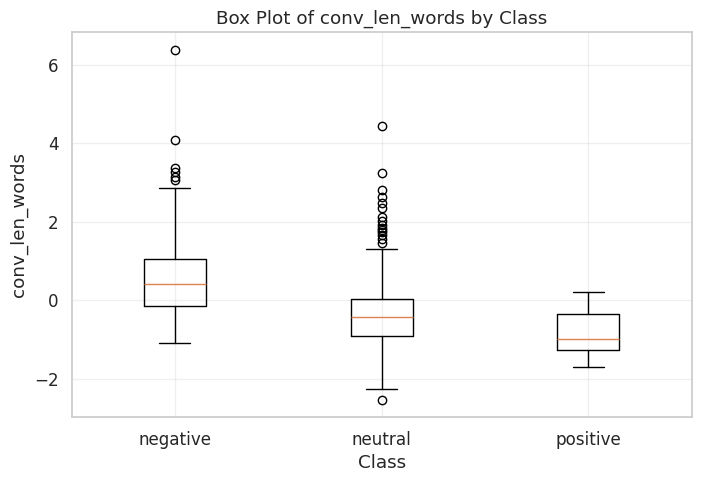

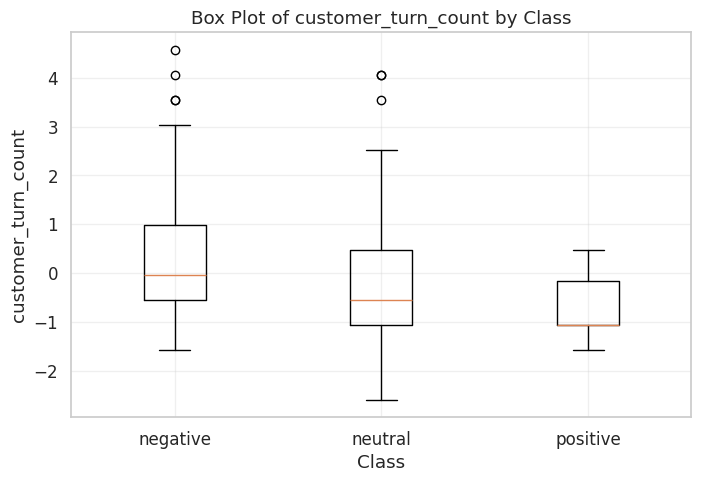

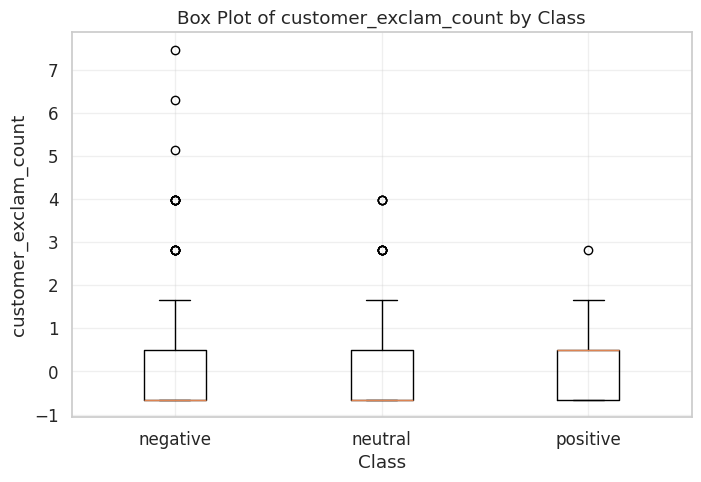

In [11]:
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, kruskal

# Numeric columns to test
numeric_feature_cols = [
    "conv_len_words",
    "customer_turn_count",
    "customer_exclam_count"
]

print("=" * 80)
print("P-VALUE ANALYSIS FOR NUMERIC FEATURES")
print("=" * 80)

pvalue_results = []

for col in numeric_feature_cols:
    print(f"\nFeature: {col}")

    # Groups by class label
    groups = [
        train_df_base.loc[train_df_base["labels"] == label, col].dropna().values
        for label in sorted(train_df_base["labels"].unique())
    ]

    # ANOVA
    anova_stat, anova_p = f_oneway(*groups)

    # Kruskal-Wallis
    kruskal_stat, kruskal_p = kruskal(*groups)

    pvalue_results.append({
        "feature": col,
        "anova_p_value": anova_p,
        "kruskal_p_value": kruskal_p
    })

    print(f"ANOVA p-value        : {anova_p:.6f}")
    print(f"Kruskal-Wallis p-value: {kruskal_p:.6f}")

pvalue_results_df = pd.DataFrame(pvalue_results).sort_values("kruskal_p_value")
print("\nSummary of p-values:")
print(pvalue_results_df)

significant_features = pvalue_results_df.loc[
    pvalue_results_df["kruskal_p_value"] < 0.05, "feature"
].tolist()

print("\nFeatures significant at p < 0.05 (based on Kruskal-Wallis):")
print(significant_features)

print("\n" + "=" * 80)
print("BOX PLOTS")
print("=" * 80)

label_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

for col in numeric_feature_cols:
    data_to_plot = [
        train_df_base.loc[train_df_base["labels"] == label, col].dropna().values
        for label in sorted(train_df_base["labels"].unique())
    ]

    plot_labels = [
        label_names.get(label, str(label))
        for label in sorted(train_df_base["labels"].unique())
    ]

    plt.figure(figsize=(8, 5))
    plt.boxplot(data_to_plot, tick_labels=plot_labels)
    plt.title(f"Box Plot of {col} by Class")
    plt.xlabel("Class")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()


CORRELATION ANALYSIS

Correlation matrix:
                     conv_len_words  customer_turn_count
conv_len_words             1.000000             0.734416
customer_turn_count        0.734416             1.000000

Highly correlated pairs (|corr| > 0.7):
conv_len_words - customer_turn_count: 0.734


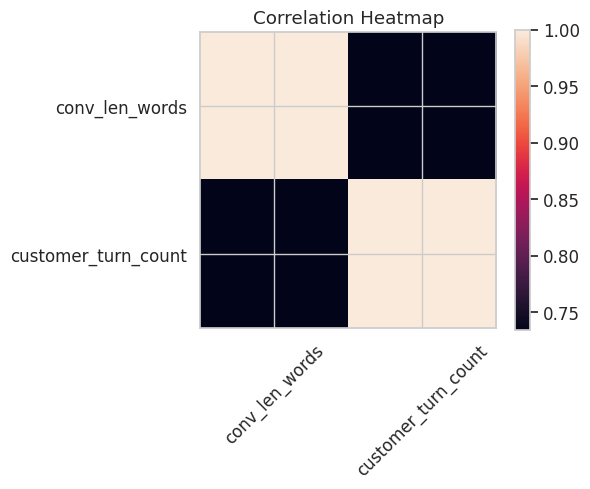

In [16]:
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Correlation matrix
corr_matrix = train_df_base[numeric_feature_cols].corr()

print("\nCorrelation matrix:")
print(corr_matrix)

# Identify highly correlated pairs
print("\nHighly correlated pairs (|corr| > 0.7):")

high_corr_pairs = []

for i in range(len(numeric_feature_cols)):
    for j in range(i + 1, len(numeric_feature_cols)):
        f1 = numeric_feature_cols[i]
        f2 = numeric_feature_cols[j]
        corr_val = corr_matrix.loc[f1, f2]

        if abs(corr_val) > 0.7:
            high_corr_pairs.append((f1, f2, corr_val))
            print(f"{f1} - {f2}: {corr_val:.3f}")

if len(high_corr_pairs) == 0:
    print("No highly correlated feature pairs found.")

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The distribution of the engineered numerical features shows that conversation length and customer interaction patterns differ across sentiment classes, with negative conversations tending to be longer and involving more customer turns. This indicates that these features capture behavioral signals. In contrast, the neutral and positive classes appear more similar in terms of length and interaction frequency; however, it is observed that some positive cases include exclamation marks, which may represent sentiment that is not explicitly reflected in the words themselves. This suggests that even these numerical features can provide additional nuance in the model adn were therefore included in the following experiments.

Oversampling with weighted cross entropy and numerical features


In [20]:
import os
import random
import re
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer
)

numeric_feature_cols = ['conv_len_words']
# Model
class RobertaHybridNumericClassifier(nn.Module):
    def __init__(self, model_name, num_labels, num_numeric_features):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.num_numeric_features = num_numeric_features

        text_hidden = self.roberta.config.hidden_size

        if num_numeric_features > 0:
            self.numeric_projection = nn.Sequential(
                nn.Linear(num_numeric_features, 32),
                nn.ReLU(),
                nn.Dropout(0.1)
            )
            combined_size = text_hidden + 32
        else:
            self.numeric_projection = None
            combined_size = text_hidden

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, input_ids, attention_mask, numeric_features=None, labels=None, loss_weights=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]

        if self.num_numeric_features > 0:
            numeric_repr = self.numeric_projection(numeric_features.float())
            final_input = torch.cat((text_output, numeric_repr), dim=1)
        else:
            final_input = text_output

        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            if loss_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}


class HybridNumericDataCollator:
    def __init__(self, tokenizer, numeric_feature_cols):
        self.tokenizer = tokenizer
        self.numeric_feature_cols = numeric_feature_cols

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        if len(self.numeric_feature_cols) > 0:
            batch["numeric_features"] = torch.tensor(
                [f["numeric_features"] for f in features],
                dtype=torch.float
            )

        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

class HybridNumericTrainer(Trainer):
    def __init__(self, loss_weights=None, use_numeric_features=True, **kwargs):
        super().__init__(**kwargs)
        self.loss_weights = loss_weights
        self.use_numeric_features = use_numeric_features

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = self.loss_weights.to(model.device) if self.loss_weights is not None else None

        model_inputs = {
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"],
            "labels": inputs["labels"],
            "loss_weights": weights
        }

        if self.use_numeric_features:
            model_inputs["numeric_features"] = inputs["numeric_features"]

        outputs = model(**model_inputs)
        loss = outputs["loss"]

        return (loss, outputs) if return_outputs else loss


# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }


# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

def tokenize_with_numeric(examples, numeric_feature_cols):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    output = {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }

    if len(numeric_feature_cols) > 0:
        numeric_data = []
        for row_idx in range(len(examples["text"])):
            numeric_data.append([examples[col][row_idx] for col in numeric_feature_cols])
        output["numeric_features"] = numeric_data

    return output


all_results = []

set_seed(SEED)
torch.cuda.empty_cache()

feature_tag = "_".join(numeric_feature_cols) if len(numeric_feature_cols) > 0 else "no_numeric"
experiment_name = f"hybrid-roberta-tail-oversample-weighted-numeric-{feature_tag}"

print("\n" + "=" * 80)
print(f"Running experiment: {experiment_name}")
print(f"Numeric features: {numeric_feature_cols}")
print("=" * 80)

wandb.init(
    project=PROJECT_NAME,
    name=experiment_name,
    reinit=True,
    config={
        "learning_rate": 2e-5,
        "epochs": 5,
        "batch_size": 8,
        "sampling": "oversample_smallest_class_x4",
        "loss": "weighted_cross_entropy",
        "model_type": "hybrid_roberta_numeric",
        "truncation": "tail",
        "seed": SEED,
        "numeric_features": numeric_feature_cols
    }
)

train_df = train_df_base.copy()
val_df = val_df_base.copy()

# Class weights from original distribution before oversampling
original_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["labels"]),
    y=train_df["labels"]
)
original_weights_tensor = torch.tensor(original_weights, dtype=torch.float)
print(f"Original class weights: {original_weights}")

# Oversample smallest class
train_df = oversample_smallest_class(
    train_df,
    label_col="labels",
    multiplier=4,
    seed=SEED
)

print("Post-oversample distribution:")
print(train_df["labels"].value_counts())

# Convert to Dataset
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

# Tokenize
train_dataset = train_dataset.map(
    lambda examples: tokenize_with_numeric(examples, numeric_feature_cols),
    batched=True
)
val_dataset = val_dataset.map(
    lambda examples: tokenize_with_numeric(examples, numeric_feature_cols),
    batched=True
)

keep_cols = ["input_ids", "attention_mask", "labels"]
if len(numeric_feature_cols) > 0:
    keep_cols.append("numeric_features")

train_dataset = train_dataset.remove_columns(
    [c for c in train_dataset.column_names if c not in keep_cols]
)
val_dataset = val_dataset.remove_columns(
    [c for c in val_dataset.column_names if c not in keep_cols]
)

# Model
model = RobertaHybridNumericClassifier(
    model_name="roberta-base",
    num_labels=3,
    num_numeric_features=len(numeric_feature_cols)
)
model.roberta.resize_token_embeddings(len(tokenizer))

training_args = TrainingArguments(
    output_dir=f"./results_{feature_tag}",
    seed=SEED,
    data_seed=SEED,
    full_determinism=True,
    dataloader_num_workers=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    logging_first_step=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="wandb",
    remove_unused_columns=False,
    fp16=torch.cuda.is_available()
)

trainer = HybridNumericTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=HybridNumericDataCollator(tokenizer, numeric_feature_cols),
    compute_metrics=compute_metrics,
    loss_weights=original_weights_tensor,
    use_numeric_features=(len(numeric_feature_cols) > 0)
)

trainer.train()

preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

report = classification_report(
    preds_output.label_ids,
    y_pred,
    target_names=["negative", "neutral", "positive"],
    output_dict=True
)

print(classification_report(
    preds_output.label_ids,
    y_pred,
    target_names=["negative", "neutral", "positive"]
))

wandb.log({
    "final_accuracy": report["accuracy"],
    "final_f1_macro": report["macro avg"]["f1-score"]
})

all_results.append({
    "features": ", ".join(numeric_feature_cols) if len(numeric_feature_cols) > 0 else "no_numeric",
    "accuracy": report["accuracy"],
    "f1_macro": report["macro avg"]["f1-score"]
})

wandb.finish()

# Summary
results_df = pd.DataFrame(all_results).sort_values("f1_macro", ascending=False).reset_index(drop=True)

print("\nOverall experiment summary:")
print(results_df)


Running experiment: hybrid-roberta-tail-oversample-weighted-numeric-conv_len_words
Numeric features: ['conv_len_words']


Original class weights: [ 0.79038855  0.59507313 18.4047619 ]
Post-oversample distribution:
labels
1    433
0    326
2     56
Name: count, dtype: int64


Map:   0%|          | 0/815 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (694 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/194 [00:00<?, ? examples/s]

...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.707677,0.515849,0.876289,0.597185
2,0.340162,0.743882,0.855670,0.578045
3,0.299592,0.805706,0.829897,0.559110
4,0.137389,0.573284,0.922680,0.752779
5,0.049345,0.583955,0.912371,0.745422


              precision    recall  f1-score   support

    negative       0.93      0.93      0.93        82
     neutral       0.93      0.94      0.93       109
    positive       0.50      0.33      0.40         3

    accuracy                           0.92       194
   macro avg       0.78      0.73      0.75       194
weighted avg       0.92      0.92      0.92       194



eval/accuracy,▄▃▁█▇
eval/f1_macro,▂▂▁██
eval/loss,▁▇█▂▃
eval/runtime,▃▄█▁▄
eval/samples_per_second,▅▅▁█▅
eval/steps_per_second,▅▅▁█▅
final_accuracy,▁
final_f1_macro,▁
test/accuracy,▁
test/f1_macro,▁
+9,...



Overall experiment summary:
         features  accuracy  f1_macro
0  conv_len_words   0.92268  0.752779


Oversampling with weighted loss, categorical features and numerical features.

In [21]:
import os
import random
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer,
    set_seed
)

SEED = 42
PROJECT_NAME = "DI725_Assignment_1"

set_seed(SEED)

def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

def extract_customer_segments(text):
    text = str(text)
    pattern = r"<cust>\s*(.*?)(?=(<cust>|<agent>|$))"
    matches = re.findall(pattern, text, flags=re.DOTALL | re.IGNORECASE)
    customer_segments = [m[0].strip() for m in matches if m[0].strip()]
    return customer_segments

def add_numerical_features(df):
    df = df.copy()

    df["conv_len_words"] = df["text"].astype(str).apply(
        lambda x: len(re.findall(r"\b\w+\b", x))
    )

    df["customer_turn_count"] = df["text"].astype(str).apply(
        lambda x: len(extract_customer_segments(x))
    )

    df["customer_exclam_count"] = df["text"].astype(str).apply(
        lambda x: sum(seg.count("!") for seg in extract_customer_segments(x))
    )

    return df

def oversample_smallest_class(train_df, label_col="labels", multiplier=4, seed=42):
    counts = train_df[label_col].value_counts()
    min_class = counts.idxmin()
    min_size = counts.min()
    max_size = counts.max()

    minority_df = train_df[train_df[label_col] == min_class]
    target_size = min(min_size * multiplier, max_size)

    upsampled_minority = minority_df.sample(
        n=target_size,
        replace=True,
        random_state=seed
    )

    train_df = pd.concat(
        [train_df[train_df[label_col] != min_class], upsampled_minority],
        axis=0
    ).sample(frac=1, random_state=seed).reset_index(drop=True)

    return train_df

def standardize_numeric_features(train_df, val_df, feature_cols):
    train_df = train_df.copy()
    val_df = val_df.copy()

    for col in feature_cols:
        mean_val = train_df[col].mean()
        std_val = train_df[col].std()
        if std_val == 0 or pd.isna(std_val):
            std_val = 1.0

        train_df[col] = (train_df[col] - mean_val) / std_val
        val_df[col] = (val_df[col] - mean_val) / std_val

    return train_df, val_df

def encode_categorical_features(train_df, val_df, cat_cols):
    train_df = train_df.copy()
    val_df = val_df.copy()
    encoders = {}

    for col in cat_cols:
        le = LabelEncoder()

        train_df[col] = train_df[col].astype(str)
        val_df[col] = val_df[col].astype(str)

        le.fit(train_df[col])

        known_classes = set(le.classes_)
        val_df[col] = val_df[col].apply(lambda x: x if x in known_classes else "__UNK__")

        if "__UNK__" not in known_classes:
            le.classes_ = np.append(le.classes_, "__UNK__")

        train_df[col] = le.transform(train_df[col])
        val_df[col] = le.transform(val_df[col])

        encoders[col] = le

    cat_dims = [(int(train_df[col].nunique()), 16) for col in cat_cols]
    return train_df, val_df, encoders, cat_dims

# Hybrid model, text + categorical + numerical
class RobertaHybridCatNumClassifier(nn.Module):
    def __init__(self, model_name, num_labels, cat_dims, num_numeric_features):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.num_numeric_features = num_numeric_features
        self.num_categorical_features = len(cat_dims)

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings, emb_dim)
            for num_embeddings, emb_dim in cat_dims
        ])

        cat_total_dim = sum(emb_dim for _, emb_dim in cat_dims)

        if num_numeric_features > 0:
            self.numeric_projection = nn.Sequential(
                nn.Linear(num_numeric_features, 32),
                nn.ReLU(),
                nn.Dropout(0.1)
            )
            numeric_dim = 32
        else:
            self.numeric_projection = None
            numeric_dim = 0

        combined_size = self.roberta.config.hidden_size + cat_total_dim + numeric_dim

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(
        self,
        input_ids,
        attention_mask,
        categorical_inputs,
        numeric_features=None,
        labels=None,
        loss_weights=None
    ):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]

        cat_outputs = []
        for i, emb in enumerate(self.cat_embeddings):
            cat_outputs.append(emb(categorical_inputs[:, i].long()))
        cat_repr = torch.cat(cat_outputs, dim=1)

        if self.num_numeric_features > 0:
            numeric_repr = self.numeric_projection(numeric_features.float())
            final_input = torch.cat((text_output, cat_repr, numeric_repr), dim=1)
        else:
            final_input = torch.cat((text_output, cat_repr), dim=1)

        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            if loss_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}


# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

def tokenize_with_cat_num(examples, numeric_feature_cols, categorical_cols):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    output = {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }

    numeric_data = []
    for row_idx in range(len(examples["text"])):
        numeric_data.append([examples[col][row_idx] for col in numeric_feature_cols])
    output["numeric_features"] = numeric_data

    cat_data = []
    for row_idx in range(len(examples["text"])):
        cat_data.append([examples[col][row_idx] for col in categorical_cols])
    output["categorical_inputs"] = cat_data

    return output


class HybridCatNumDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        batch["categorical_inputs"] = torch.tensor(
            [f["categorical_inputs"] for f in features],
            dtype=torch.long
        )

        batch["numeric_features"] = torch.tensor(
            [f["numeric_features"] for f in features],
            dtype=torch.float
        )

        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

class HybridCatNumTrainer(Trainer):
    def __init__(self, loss_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.loss_weights = loss_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = self.loss_weights.to(model.device) if self.loss_weights is not None else None

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            categorical_inputs=inputs["categorical_inputs"],
            numeric_features=inputs["numeric_features"],
            labels=inputs["labels"],
            loss_weights=weights
        )

        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Load base data
train_df_base = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df_base = pd.read_csv("data/preprocessed/preprocessed_val.csv")

train_df_base = normalize_label_column(train_df_base)
val_df_base = normalize_label_column(val_df_base)

required_cols = ["text", "labels", "issue_area", "issue_category"]
train_df_base = train_df_base.dropna(subset=required_cols).copy()
val_df_base = val_df_base.dropna(subset=required_cols).copy()

train_df_base["labels"] = train_df_base["labels"].astype(int)
val_df_base["labels"] = val_df_base["labels"].astype(int)

train_df_base = add_numerical_features(train_df_base)
val_df_base = add_numerical_features(val_df_base)

# Use both categorical variables and only conv_len_words
categorical_cols = ["issue_area", "issue_category"]
numeric_feature_cols = ["conv_len_words"]

all_results = []

set_seed(SEED)
torch.cuda.empty_cache()

cat_tag = "_".join(categorical_cols)
num_tag = "_".join(numeric_feature_cols)
experiment_name = f"hybrid-roberta-tail-oversample-weighted-cat-{cat_tag}-num-{num_tag}"

print("\n" + "=" * 90)
print(f"Running experiment: {experiment_name}")
print(f"Categorical features: {categorical_cols}")
print(f"Numeric features: {numeric_feature_cols}")
print("=" * 90)

wandb.init(
    project=PROJECT_NAME,
    name=experiment_name,
    reinit=True,
    config={
        "learning_rate": 2e-5,
        "epochs": 5,
        "batch_size": 8,
        "sampling": "oversample_smallest_class_x4",
        "loss": "weighted_cross_entropy",
        "model_type": "hybrid_roberta_cat_num",
        "truncation": "tail",
        "seed": SEED,
        "categorical_features": categorical_cols,
        "numeric_features": numeric_feature_cols
    }
)

train_df = train_df_base.copy()
val_df = val_df_base.copy()

# class weights from original distribution
original_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["labels"]),
    y=train_df["labels"]
)
original_weights_tensor = torch.tensor(original_weights, dtype=torch.float)
print(f"Original class weights: {original_weights}")

# oversample smallest class
train_df = oversample_smallest_class(
    train_df,
    label_col="labels",
    multiplier=4,
    seed=SEED
)

print("Post-oversample distribution:")
print(train_df["labels"].value_counts())

# standardize only conv_len_words
train_df, val_df = standardize_numeric_features(
    train_df,
    val_df,
    numeric_feature_cols
)

# encode both categorical features
train_df, val_df, encoders, cat_dims = encode_categorical_features(
    train_df,
    val_df,
    categorical_cols
)

# dataset
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

train_dataset = train_dataset.map(
    lambda examples: tokenize_with_cat_num(examples, numeric_feature_cols, categorical_cols),
    batched=True
)
val_dataset = val_dataset.map(
    lambda examples: tokenize_with_cat_num(examples, numeric_feature_cols, categorical_cols),
    batched=True
)

keep_cols = ["input_ids", "attention_mask", "labels", "numeric_features", "categorical_inputs"]

train_dataset = train_dataset.remove_columns(
    [c for c in train_dataset.column_names if c not in keep_cols]
)
val_dataset = val_dataset.remove_columns(
    [c for c in val_dataset.column_names if c not in keep_cols]
)

# model
model = RobertaHybridCatNumClassifier(
    model_name="roberta-base",
    num_labels=3,
    cat_dims=cat_dims,
    num_numeric_features=len(numeric_feature_cols)
)
model.roberta.resize_token_embeddings(len(tokenizer))

training_args = TrainingArguments(
    output_dir=f"./results_cat_{cat_tag}_num_{num_tag}",
    seed=SEED,
    data_seed=SEED,
    full_determinism=True,
    dataloader_num_workers=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    logging_first_step=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="wandb",
    remove_unused_columns=False,
    fp16=torch.cuda.is_available()
)

trainer = HybridCatNumTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=HybridCatNumDataCollator(tokenizer),
    compute_metrics=compute_metrics,
    loss_weights=original_weights_tensor
)

trainer.train()

preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

report = classification_report(
    preds_output.label_ids,
    y_pred,
    target_names=["negative", "neutral", "positive"],
    output_dict=True
)

print(classification_report(
    preds_output.label_ids,
    y_pred,
    target_names=["negative", "neutral", "positive"]
))

wandb.log({
    "final_accuracy": report["accuracy"],
    "final_f1_macro": report["macro avg"]["f1-score"]
})

all_results.append({
    "categorical_features": ", ".join(categorical_cols),
    "numeric_features": ", ".join(numeric_feature_cols),
    "accuracy": report["accuracy"],
    "f1_macro": report["macro avg"]["f1-score"]
})

wandb.finish()

# Summary
results_df = pd.DataFrame(all_results).sort_values("f1_macro", ascending=False).reset_index(drop=True)

print("\nOverall experiment summary:")
print(results_df)


Running experiment: hybrid-roberta-tail-oversample-weighted-cat-issue_area_issue_category-num-conv_len_words
Categorical features: ['issue_area', 'issue_category']
Numeric features: ['conv_len_words']


Original class weights: [ 0.79038855  0.59507313 18.4047619 ]
Post-oversample distribution:
labels
1    433
0    326
2     56
Name: count, dtype: int64


Map:   0%|          | 0/815 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (694 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/194 [00:00<?, ? examples/s]

...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.853503,0.887595,0.458763,0.371872
2,0.491085,0.595617,0.876289,0.591293
3,0.193790,0.442820,0.876289,0.597197
4,0.255889,0.548651,0.896907,0.605458
5,0.069366,0.537101,0.912371,0.725113


              precision    recall  f1-score   support

    negative       0.95      0.89      0.92        82
     neutral       0.90      0.94      0.92       109
    positive       0.33      0.33      0.33         3

    accuracy                           0.91       194
   macro avg       0.73      0.72      0.73       194
weighted avg       0.91      0.91      0.91       194



eval/accuracy,▁▇▇██
eval/f1_macro,▁▅▅▆█
eval/loss,█▃▁▃▂
eval/runtime,█▁▁▂▄
eval/samples_per_second,▁██▇▅
eval/steps_per_second,▁██▇▅
final_accuracy,▁
final_f1_macro,▁
test/accuracy,▁
test/f1_macro,▁
+9,...



Overall experiment summary:
         categorical_features numeric_features  accuracy  f1_macro
0  issue_area, issue_category   conv_len_words  0.912371  0.725113


# Fine Tuning Hybrid Models

The numerical and categroical+numerical hybrid model results were promising therefore were used in further hyperparameter tuning.

Categorical Sweep

In [51]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer,
    set_seed
)

SEED = 42
PROJECT_NAME = "DI725_Assignment_1_sweep_categorical_only"

# FIXED categorical embedding dimension
CAT_EMBEDDING_DIM = 16

set_seed(SEED)

# -----------------------------
# Data Loading
# -----------------------------
train_df_base = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df_base = pd.read_csv("data/preprocessed/preprocessed_val.csv")

def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels", "issue_area", "issue_category"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label", "issue_area", "issue_category"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

train_df_base = normalize_label_column(train_df_base)
val_df_base = normalize_label_column(val_df_base)

train_df_base["labels"] = train_df_base["labels"].astype(int)
val_df_base["labels"] = val_df_base["labels"].astype(int)

# -----------------------------
# Tokenizer
# -----------------------------
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

# -----------------------------
# Model
# -----------------------------
class RobertaHybridClassifier(nn.Module):
    def __init__(self, model_name, num_labels, cat_dims, classifier_dropout):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings, emb_dim)
            for num_embeddings, emb_dim in cat_dims
        ])

        combined_size = self.roberta.config.hidden_size + sum(emb_dim for _, emb_dim in cat_dims)

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, input_ids, attention_mask, categorical_inputs, labels=None, loss_weights=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]

        cat_outputs = [
            emb(categorical_inputs[:, i].long())
            for i, emb in enumerate(self.embeddings)
        ]
        cat_combined = torch.cat(cat_outputs, dim=1)

        final_input = torch.cat((text_output, cat_combined), dim=1)
        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            if loss_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

# -----------------------------
# Tokenization
# -----------------------------
def tokenize_hybrid(examples, cat_cols):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    cat_data = []
    for row_idx in range(len(examples["text"])):
        cat_data.append([examples[col][row_idx] for col in cat_cols])

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "categorical_inputs": cat_data
    }

# -----------------------------
# Collator
# -----------------------------
class HybridDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        batch["categorical_inputs"] = torch.tensor(
            [f["categorical_inputs"] for f in features],
            dtype=torch.long
        )
        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

# -----------------------------
# Trainer
# -----------------------------
class HybridTrainer(Trainer):
    def __init__(self, loss_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.loss_weights = loss_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = self.loss_weights.to(model.device) if self.loss_weights is not None else None

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            categorical_inputs=inputs["categorical_inputs"],
            labels=inputs["labels"],
            loss_weights=weights
        )

        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

# -----------------------------
# Metrics
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    report = classification_report(
        labels,
        preds,
        target_names=["negative", "neutral", "positive"],
        output_dict=True
    )

    return {
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"],
        "recall_macro": report["macro avg"]["recall"],

        "precision_negative": report["negative"]["precision"],
        "recall_negative": report["negative"]["recall"],
        "f1_negative": report["negative"]["f1-score"],

        "precision_neutral": report["neutral"]["precision"],
        "recall_neutral": report["neutral"]["recall"],
        "f1_neutral": report["neutral"]["f1-score"],

        "precision_positive": report["positive"]["precision"],
        "recall_positive": report["positive"]["recall"],
        "f1_positive": report["positive"]["f1-score"],
    }

# -----------------------------
# Oversampling helper
# -----------------------------
def oversample_smallest_class(train_df, label_col="labels", multiplier=4, seed=42):
    counts = train_df[label_col].value_counts()
    min_class = counts.idxmin()
    min_size = counts.min()
    max_size = counts.max()

    minority_df = train_df[train_df[label_col] == min_class]
    target_size = min(min_size * multiplier, max_size)

    upsampled_minority = minority_df.sample(
        n=target_size,
        replace=True,
        random_state=seed
    )

    train_df = pd.concat(
        [train_df[train_df[label_col] != min_class], upsampled_minority],
        axis=0
    ).sample(frac=1, random_state=seed).reset_index(drop=True)

    return train_df

# -----------------------------
# Fixed categorical setup
# -----------------------------
cat_cols = ["issue_area", "issue_category"]

# -----------------------------
# Sweep training function
# -----------------------------
def train_sweep():
    wandb.init(project=PROJECT_NAME)
    config = wandb.config

    run_name = (
        f"lr{config.learning_rate}_"
        f"wd{config.weight_decay}_"
        f"drop{config.classifier_dropout}"
    )
    wandb.run.name = run_name

    set_seed(SEED)
    torch.cuda.empty_cache()

    train_df = train_df_base.copy()
    val_df = val_df_base.copy()

    original_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_df["labels"]),
        y=train_df["labels"]
    )
    original_weights_tensor = torch.tensor(original_weights, dtype=torch.float)

    train_df = oversample_smallest_class(
        train_df,
        label_col="labels",
        multiplier=4,
        seed=SEED
    )

    # Encode categorical columns
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()

        train_df[col] = train_df[col].astype(str)
        val_df[col] = val_df[col].astype(str)

        le.fit(train_df[col])

        known_classes = set(le.classes_)
        val_df[col] = val_df[col].apply(lambda x: x if x in known_classes else "__UNK__")

        if "__UNK__" not in known_classes:
            le.classes_ = np.append(le.classes_, "__UNK__")

        train_df[col] = le.transform(train_df[col])
        val_df[col] = le.transform(val_df[col])

        encoders[col] = le

    cat_dims = [(int(train_df[col].nunique()), CAT_EMBEDDING_DIM) for col in cat_cols]

    train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True)).map(
        lambda examples: tokenize_hybrid(examples, cat_cols),
        batched=True
    )
    val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True)).map(
        lambda examples: tokenize_hybrid(examples, cat_cols),
        batched=True
    )

    keep_cols = ["input_ids", "attention_mask", "labels", "categorical_inputs"]
    train_dataset = train_dataset.remove_columns(
        [c for c in train_dataset.column_names if c not in keep_cols]
    )
    val_dataset = val_dataset.remove_columns(
        [c for c in val_dataset.column_names if c not in keep_cols]
    )

    model = RobertaHybridClassifier(
        model_name="roberta-base",
        num_labels=3,
        cat_dims=cat_dims,
        classifier_dropout=config.classifier_dropout
    )
    model.roberta.resize_token_embeddings(len(tokenizer))

    training_args = TrainingArguments(
        output_dir=f"./sweep_results_categorical_only_{wandb.run.id}",
        seed=SEED,
        data_seed=SEED,
        full_determinism=True,
        dataloader_num_workers=0,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        logging_strategy="steps",
        logging_steps=10,
        logging_first_step=True,
        learning_rate=config.learning_rate,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=config.weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="wandb",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    )

    trainer = HybridTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=HybridDataCollator(tokenizer),
        compute_metrics=compute_metrics,
        loss_weights=original_weights_tensor
    )

    trainer.train()

    preds_output = trainer.predict(val_dataset)
    y_pred = np.argmax(preds_output.predictions, axis=1)

    print("\nFULL CLASSIFICATION REPORT:")
    print(classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

    report = classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"],
        output_dict=True
    )

    wandb.log({
        "final_accuracy": report["accuracy"],
        "final_f1_macro": report["macro avg"]["f1-score"],
        "final_recall_macro": report["macro avg"]["recall"],

        "final_precision_negative": report["negative"]["precision"],
        "final_recall_negative": report["negative"]["recall"],
        "final_f1_negative": report["negative"]["f1-score"],

        "final_precision_neutral": report["neutral"]["precision"],
        "final_recall_neutral": report["neutral"]["recall"],
        "final_f1_neutral": report["neutral"]["f1-score"],

        "final_precision_positive": report["positive"]["precision"],
        "final_recall_positive": report["positive"]["recall"],
        "final_f1_positive": report["positive"]["f1-score"],
    })

# -----------------------------
# Sweep config
# -----------------------------
sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "eval/f1_macro",
        "goal": "maximize"
    },
    "parameters": {
        "learning_rate": {
            "values": [1e-5, 2e-5, 3e-5]
        },
        "classifier_dropout": {
            "values": [0.1, 0.2, 0.3]
        },
        "weight_decay": {
            "values": [0.0, 0.01, 0.05]
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project=PROJECT_NAME)
print("Sweep ID:", sweep_id)

wandb.agent(sweep_id, function=train_sweep, count=5)

Create sweep with ID: h4y9t37a
Sweep URL: https://wandb.ai/ayseatci00-/DI725_Assignment_1_sweep_categorical_only/sweeps/h4y9t37a
Sweep ID: h4y9t37a


wandb: Agent Starting Run: tftiuu45 with config:
wandb: 	classifier_dropout: 0.1
wandb: 	learning_rate: 3e-05
wandb: 	weight_decay: 0
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Map:   0%|          | 0/815 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (694 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/194 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Recall Macro,Precision Negative,Recall Negative,F1 Negative,Precision Neutral,Recall Neutral,F1 Neutral,Precision Positive,Recall Positive,F1 Positive
1,0.829670,0.825844,0.587629,0.378876,0.431193,0.525641,1.000000,0.689076,0.941176,0.293578,0.447552,0.000000,0.000000,0.000000
2,0.424822,0.677312,0.855670,0.577841,0.573096,0.928571,0.792683,0.855263,0.834711,0.926606,0.878261,0.000000,0.000000,0.000000
3,0.240046,0.689808,0.850515,0.659067,0.692188,0.797980,0.963415,0.872928,0.944444,0.779817,0.854271,0.200000,0.333333,0.250000
4,0.327913,0.571777,0.886598,0.746291,0.817620,0.882353,0.914634,0.898204,0.922330,0.871560,0.896226,0.333333,0.666667,0.444444
5,0.026957,0.662215,0.907216,0.721584,0.719786,0.935897,0.890244,0.912500,0.902655,0.935780,0.918919,0.333333,0.333333,0.333333



FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    negative       0.88      0.91      0.90        82
     neutral       0.92      0.87      0.90       109
    positive       0.33      0.67      0.44         3

    accuracy                           0.89       194
   macro avg       0.71      0.82      0.75       194
weighted avg       0.90      0.89      0.89       194



eval/accuracy,▁▇▇██
eval/f1_macro,▁▅▆██
eval/f1_negative,▁▆▇██
eval/f1_neutral,▁▇▇██
eval/f1_positive,▁▁▅█▆
eval/loss,█▄▄▁▃
eval/precision_negative,▁█▆▇█
eval/precision_neutral,█▁█▇▅
eval/precision_positive,▁▁▅██
eval/recall_macro,▁▄▆█▆
+39,...


Loading model weights with best F1 to test

In [52]:
import os

base_dir = "./sweep_results_categorical_only_tftiuu45"

checkpoint_dirs = []
for root, dirs, files in os.walk(base_dir):
    for d in dirs:
        if "checkpoint" in d:
            checkpoint_dirs.append(os.path.join(root, d))

# sort by step number
checkpoint_dirs = sorted(checkpoint_dirs, key=lambda x: int(x.split("-")[-1]))

best_checkpoint = checkpoint_dirs[-1]
print("Using checkpoint:", best_checkpoint)

Using checkpoint: ./sweep_results_categorical_only_tftiuu45/checkpoint-306


In [53]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from datasets import Dataset
from transformers import TrainingArguments

# -------------------------------------------------
# 1) CHECKPOINT / ARCHITECTURE SETTINGS
# -------------------------------------------------
checkpoint_path = "./sweep_results_categorical_only_tftiuu45/checkpoint-306"

cat_cols = ["issue_area", "issue_category"]
cat_embedding_dim = 16
classifier_dropout = 0.1

# -------------------------------------------------
# 2) REBUILD TRAIN-SIDE PREPROCESSING OBJECTS
# -------------------------------------------------
train_df_for_test = pd.read_csv("data/preprocessed/preprocessed_train.csv")
train_df_for_test = normalize_label_column(train_df_for_test)

train_df_for_test["labels"] = train_df_for_test["labels"].astype(int)

# fit label encoders on train side
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_df_for_test[col] = train_df_for_test[col].astype(str)
    le.fit(train_df_for_test[col])

    if "__UNK__" not in le.classes_:
        le.classes_ = np.append(le.classes_, "__UNK__")

    encoders[col] = le

# match training-time embedding dimensions
cat_dims = [(int(train_df_for_test[col].astype(str).nunique()), cat_embedding_dim) for col in cat_cols]
print("cat_dims:", cat_dims)

# -------------------------------------------------
# 3) LOAD MODEL WEIGHTS
# -------------------------------------------------
model = RobertaHybridClassifier(
    model_name="roberta-base",
    num_labels=3,
    cat_dims=cat_dims,
    classifier_dropout=classifier_dropout
)
model.roberta.resize_token_embeddings(len(tokenizer))

safetensor_path = os.path.join(checkpoint_path, "model.safetensors")
bin_path = os.path.join(checkpoint_path, "pytorch_model.bin")

if os.path.exists(safetensor_path):
    from safetensors.torch import load_file
    state_dict = load_file(safetensor_path)
    model.load_state_dict(state_dict)
elif os.path.exists(bin_path):
    state_dict = torch.load(bin_path, map_location="cpu")
    model.load_state_dict(state_dict)
else:
    raise FileNotFoundError(f"No model weights found in {checkpoint_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# -------------------------------------------------
# 4) LOAD AND PREPROCESS TEST
# -------------------------------------------------
test_df = pd.read_csv("data/preprocessed/preprocessed_test.csv")

if "labels" in test_df.columns or "label" in test_df.columns:
    test_df = normalize_label_column(test_df)
    test_df["labels"] = test_df["labels"].astype(int)

test_df = test_df.dropna(subset=["text", "issue_area", "issue_category"]).copy()

# encode categoricals with TRAIN encoders
for col in cat_cols:
    le = encoders[col]
    known_classes = set(le.classes_)
    test_df[col] = test_df[col].astype(str).apply(lambda x: x if x in known_classes else "__UNK__")
    test_df[col] = le.transform(test_df[col])

# -------------------------------------------------
# 5) BUILD DATASET
# -------------------------------------------------
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

test_dataset = test_dataset.map(
    lambda examples: tokenize_hybrid(examples, cat_cols),
    batched=True
)

keep_cols = ["input_ids", "attention_mask", "categorical_inputs"]
if "labels" in test_dataset.column_names:
    keep_cols.append("labels")

test_dataset = test_dataset.remove_columns(
    [c for c in test_dataset.column_names if c not in keep_cols]
)

# -------------------------------------------------
# 6) PREDICT
# -------------------------------------------------
predict_trainer = HybridTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./tmp_test_output_categorical_only",
        per_device_eval_batch_size=8,
        report_to="none",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    ),
    data_collator=HybridDataCollator(tokenizer),
    compute_metrics=compute_metrics
)

preds_output = predict_trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

test_df["predicted_label"] = y_pred
label_map = {0: "negative", 1: "neutral", 2: "positive"}
test_df["predicted_label_name"] = test_df["predicted_label"].map(label_map)

print(test_df[["text", "issue_area", "issue_category", "predicted_label", "predicted_label_name"]].head())

if "labels" in test_df.columns:
    print("\nTest classification report:")
    print(classification_report(
        test_df["labels"],
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

test_df.to_csv("test_predictions_categorical_only_tftiuu45.csv", index=False)
print("\nSaved: test_predictions_categorical_only_tftiuu45.csv")

cat_dims: [(6, 16), (40, 16)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/30 [00:00<?, ? examples/s]

                                                text  issue_area  \
0  <agent> Thank you for calling BrownBox Custome...           4   
1  <agent> Thank you for calling BrownBox Custome...           1   
2  <agent> Thank you for calling BrownBox Custome...           0   
3  <agent> Thank you for calling BrownBox Custome...           2   
4  <agent> Thank you for calling BrownBox Custome...           0   

   issue_category  predicted_label predicted_label_name  
0              25                1              neutral  
1               1                0             negative  
2               6                0             negative  
3              22                0             negative  
4              23                0             negative  

Test classification report:
              precision    recall  f1-score   support

    negative       0.82      0.90      0.86        10
     neutral       0.78      0.70      0.74        10
    positive       0.90      0.90      0.90        

Numerical sweep

In [54]:
import os
import random
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer,
    set_seed
)

SEED = 42
PROJECT_NAME = "DI725_Assignment_1_sweep_numeric_only"

# FIXED numeric hidden dimension
NUMERIC_HIDDEN_DIM = 32

set_seed(SEED)

def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

def add_numerical_features(df):
    df = df.copy()

    # ONLY numeric feature used
    df["conv_len_words"] = df["text"].astype(str).apply(
        lambda x: len(re.findall(r"\b\w+\b", x))
    )

    return df

def oversample_smallest_class(train_df, label_col="labels", multiplier=4, seed=42):
    counts = train_df[label_col].value_counts()
    min_class = counts.idxmin()
    min_size = counts.min()
    max_size = counts.max()

    minority_df = train_df[train_df[label_col] == min_class]
    target_size = min(min_size * multiplier, max_size)

    upsampled_minority = minority_df.sample(
        n=target_size,
        replace=True,
        random_state=seed
    )

    train_df = pd.concat(
        [train_df[train_df[label_col] != min_class], upsampled_minority],
        axis=0
    ).sample(frac=1, random_state=seed).reset_index(drop=True)

    return train_df

def standardize_numeric_features(train_df, val_df, feature_cols):
    train_df = train_df.copy()
    val_df = val_df.copy()

    for col in feature_cols:
        mean_val = train_df[col].mean()
        std_val = train_df[col].std()
        if std_val == 0 or pd.isna(std_val):
            std_val = 1.0

        train_df[col] = (train_df[col] - mean_val) / std_val
        val_df[col] = (val_df[col] - mean_val) / std_val

    return train_df, val_df

class RobertaHybridNumericClassifier(nn.Module):
    def __init__(self, model_name, num_labels, num_numeric_features, numeric_hidden_dim, classifier_dropout):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.num_numeric_features = num_numeric_features

        text_hidden = self.roberta.config.hidden_size

        if num_numeric_features > 0:
            self.numeric_projection = nn.Sequential(
                nn.Linear(num_numeric_features, numeric_hidden_dim),
                nn.ReLU(),
                nn.Dropout(classifier_dropout)
            )
            combined_size = text_hidden + numeric_hidden_dim
        else:
            self.numeric_projection = None
            combined_size = text_hidden

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, input_ids, attention_mask, numeric_features=None, labels=None, loss_weights=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]

        if self.num_numeric_features > 0:
            numeric_repr = self.numeric_projection(numeric_features.float())
            final_input = torch.cat((text_output, numeric_repr), dim=1)
        else:
            final_input = text_output

        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            if loss_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

class HybridNumericDataCollator:
    def __init__(self, tokenizer, numeric_feature_cols):
        self.tokenizer = tokenizer
        self.numeric_feature_cols = numeric_feature_cols

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        if len(self.numeric_feature_cols) > 0:
            batch["numeric_features"] = torch.tensor(
                [f["numeric_features"] for f in features],
                dtype=torch.float
            )

        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

class HybridNumericTrainer(Trainer):
    def __init__(self, loss_weights=None, use_numeric_features=True, **kwargs):
        super().__init__(**kwargs)
        self.loss_weights = loss_weights
        self.use_numeric_features = use_numeric_features

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = self.loss_weights.to(model.device) if self.loss_weights is not None else None

        model_inputs = {
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"],
            "labels": inputs["labels"],
            "loss_weights": weights
        }

        if self.use_numeric_features:
            model_inputs["numeric_features"] = inputs["numeric_features"]

        outputs = model(**model_inputs)
        loss = outputs["loss"]

        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    report = classification_report(
        labels,
        preds,
        target_names=["negative", "neutral", "positive"],
        output_dict=True
    )

    return {
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"],
        "recall_macro": report["macro avg"]["recall"],

        "precision_negative": report["negative"]["precision"],
        "recall_negative": report["negative"]["recall"],
        "f1_negative": report["negative"]["f1-score"],

        "precision_neutral": report["neutral"]["precision"],
        "recall_neutral": report["neutral"]["recall"],
        "f1_neutral": report["neutral"]["f1-score"],

        "precision_positive": report["positive"]["precision"],
        "recall_positive": report["positive"]["recall"],
        "f1_positive": report["positive"]["f1-score"],
    }

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

def tokenize_with_numeric(examples, numeric_feature_cols):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    output = {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }

    if len(numeric_feature_cols) > 0:
        numeric_data = []
        for row_idx in range(len(examples["text"])):
            numeric_data.append([examples[col][row_idx] for col in numeric_feature_cols])
        output["numeric_features"] = numeric_data

    return output

# -----------------------------
# Load base data
# -----------------------------
train_df_base = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df_base = pd.read_csv("data/preprocessed/preprocessed_val.csv")

train_df_base = normalize_label_column(train_df_base)
val_df_base = normalize_label_column(val_df_base)

train_df_base["labels"] = train_df_base["labels"].astype(int)
val_df_base["labels"] = val_df_base["labels"].astype(int)

train_df_base = add_numerical_features(train_df_base)
val_df_base = add_numerical_features(val_df_base)

numeric_feature_cols = ["conv_len_words"]

def train_sweep():
    wandb.init(project=PROJECT_NAME)
    config = wandb.config

    run_name = (
        f"lr{config.learning_rate}_"
        f"wd{config.weight_decay}_"
        f"drop{config.classifier_dropout}"
    )
    wandb.run.name = run_name

    set_seed(SEED)
    torch.cuda.empty_cache()

    train_df = train_df_base.copy()
    val_df = val_df_base.copy()

    original_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_df["labels"]),
        y=train_df["labels"]
    )
    original_weights_tensor = torch.tensor(original_weights, dtype=torch.float)

    train_df = oversample_smallest_class(
        train_df,
        label_col="labels",
        multiplier=4,
        seed=SEED
    )

    train_df, val_df = standardize_numeric_features(
        train_df,
        val_df,
        numeric_feature_cols
    )

    train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
    val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

    train_dataset = train_dataset.map(
        lambda examples: tokenize_with_numeric(examples, numeric_feature_cols),
        batched=True
    )
    val_dataset = val_dataset.map(
        lambda examples: tokenize_with_numeric(examples, numeric_feature_cols),
        batched=True
    )

    keep_cols = ["input_ids", "attention_mask", "labels"]
    if len(numeric_feature_cols) > 0:
        keep_cols.append("numeric_features")

    train_dataset = train_dataset.remove_columns(
        [c for c in train_dataset.column_names if c not in keep_cols]
    )
    val_dataset = val_dataset.remove_columns(
        [c for c in val_dataset.column_names if c not in keep_cols]
    )

    model = RobertaHybridNumericClassifier(
        model_name="roberta-base",
        num_labels=3,
        num_numeric_features=len(numeric_feature_cols),
        numeric_hidden_dim=NUMERIC_HIDDEN_DIM,
        classifier_dropout=config.classifier_dropout
    )
    model.roberta.resize_token_embeddings(len(tokenizer))

    training_args = TrainingArguments(
        output_dir=f"./sweep_results_numeric_only_{wandb.run.id}",
        seed=SEED,
        data_seed=SEED,
        full_determinism=True,
        dataloader_num_workers=0,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        logging_strategy="steps",
        logging_steps=10,
        logging_first_step=True,
        learning_rate=config.learning_rate,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=config.weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="wandb",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    )

    trainer = HybridNumericTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=HybridNumericDataCollator(tokenizer, numeric_feature_cols),
        compute_metrics=compute_metrics,
        loss_weights=original_weights_tensor,
        use_numeric_features=(len(numeric_feature_cols) > 0)
    )

    trainer.train()

    preds_output = trainer.predict(val_dataset)
    y_pred = np.argmax(preds_output.predictions, axis=1)

    print("\nFULL CLASSIFICATION REPORT:")
    print(classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

    report = classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"],
        output_dict=True
    )

    wandb.log({
        "final_accuracy": report["accuracy"],
        "final_f1_macro": report["macro avg"]["f1-score"],
        "final_recall_macro": report["macro avg"]["recall"],

        "final_precision_negative": report["negative"]["precision"],
        "final_recall_negative": report["negative"]["recall"],
        "final_f1_negative": report["negative"]["f1-score"],

        "final_precision_neutral": report["neutral"]["precision"],
        "final_recall_neutral": report["neutral"]["recall"],
        "final_f1_neutral": report["neutral"]["f1-score"],

        "final_precision_positive": report["positive"]["precision"],
        "final_recall_positive": report["positive"]["recall"],
        "final_f1_positive": report["positive"]["f1-score"],
    })

sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "eval/f1_macro",
        "goal": "maximize"
    },
    "parameters": {
        "learning_rate": {
            "values": [1e-5, 2e-5, 3e-5]
        },
        "classifier_dropout": {
            "values": [0.1, 0.2, 0.3]
        },
        "weight_decay": {
            "values": [0.0, 0.01, 0.05]
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project=PROJECT_NAME)
print("Sweep ID:", sweep_id)

wandb.agent(sweep_id, function=train_sweep, count=5)

Create sweep with ID: 0ghcg7bd
Sweep URL: https://wandb.ai/ayseatci00-/DI725_Assignment_1_sweep_numeric_only/sweeps/0ghcg7bd
Sweep ID: 0ghcg7bd


wandb: Agent Starting Run: 7g501ilw with config:
wandb: 	classifier_dropout: 0.1
wandb: 	learning_rate: 1e-05
wandb: 	weight_decay: 0.05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Map:   0%|          | 0/815 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (694 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/194 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Recall Macro,Precision Negative,Recall Negative,F1 Negative,Precision Neutral,Recall Neutral,F1 Neutral,Precision Positive,Recall Positive,F1 Positive
1,0.439488,0.578740,0.840206,0.564136,0.559894,0.924242,0.743902,0.824324,0.809524,0.935780,0.868085,0.000000,0.000000,0.000000
2,0.376714,0.538631,0.896907,0.605321,0.603603,0.946667,0.865854,0.904459,0.880342,0.944954,0.911504,0.000000,0.000000,0.000000
3,0.266578,0.731072,0.886598,0.597360,0.606549,0.833333,0.975610,0.898876,0.948454,0.844037,0.893204,0.000000,0.000000,0.000000
4,0.157518,0.672624,0.922680,0.784124,0.730974,0.925926,0.914634,0.920245,0.919643,0.944954,0.932127,1.000000,0.333333,0.500000
5,0.027842,0.737103,0.907216,0.721698,0.720793,0.925000,0.902439,0.913580,0.909910,0.926606,0.918182,0.333333,0.333333,0.333333



FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    negative       0.93      0.91      0.92        82
     neutral       0.92      0.94      0.93       109
    positive       1.00      0.33      0.50         3

    accuracy                           0.92       194
   macro avg       0.95      0.73      0.78       194
weighted avg       0.92      0.92      0.92       194



eval/accuracy,▁▆▅█▇
eval/f1_macro,▁▂▂█▆
eval/f1_negative,▁▇▆██
eval/f1_neutral,▁▆▄█▆
eval/f1_positive,▁▁▁█▆
eval/loss,▂▁█▆█
eval/precision_negative,▇█▁▇▇
eval/precision_neutral,▁▅█▇▆
eval/precision_positive,▁▁▁█▃
eval/recall_macro,▁▃▃██
+39,...


Load weights of best performing model to test

In [55]:
import os

base_dir = "./sweep_results_numeric_only_fu3012l8"

checkpoint_dirs = []
for root, dirs, files in os.walk(base_dir):
    for d in dirs:
        if "checkpoint" in d:
            checkpoint_dirs.append(os.path.join(root, d))

# sort by step number
checkpoint_dirs = sorted(checkpoint_dirs, key=lambda x: int(x.split("-")[-1]))

best_checkpoint = checkpoint_dirs[-1]
print("Using checkpoint:", best_checkpoint)

Using checkpoint: ./sweep_results_numeric_only_fu3012l8/checkpoint-510


In [57]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report
from datasets import Dataset
from transformers import TrainingArguments

# -------------------------------------------------
# 1) CHECKPOINT / ARCHITECTURE SETTINGS
# -------------------------------------------------
checkpoint_path = "./sweep_results_numeric_only_fu3012l8/checkpoint-510"


numeric_hidden_dim = 32
classifier_dropout = 0.2
numeric_feature_cols = ["conv_len_words"]

# -------------------------------------------------
# 2) REBUILD TRAIN-SIDE PREPROCESSING OBJECTS
# -------------------------------------------------
train_df_for_test = pd.read_csv("data/preprocessed/preprocessed_train.csv")
train_df_for_test = normalize_label_column(train_df_for_test)
train_df_for_test["labels"] = train_df_for_test["labels"].astype(int)

train_df_for_test = add_numerical_features(train_df_for_test)

# match training pipeline: oversample happened before standardization
train_df_for_test = oversample_smallest_class(
    train_df_for_test,
    label_col="labels",
    multiplier=4,
    seed=SEED
)

# numeric stats from training pipeline
conv_len_mean = train_df_for_test["conv_len_words"].mean()
conv_len_std = train_df_for_test["conv_len_words"].std()

if conv_len_std == 0 or pd.isna(conv_len_std):
    conv_len_std = 1.0

# -------------------------------------------------
# 3) LOAD MODEL WEIGHTS
# -------------------------------------------------
model = RobertaHybridNumericClassifier(
    model_name="roberta-base",
    num_labels=3,
    num_numeric_features=len(numeric_feature_cols),
    numeric_hidden_dim=numeric_hidden_dim,
    classifier_dropout=classifier_dropout
)
model.roberta.resize_token_embeddings(len(tokenizer))

safetensor_path = os.path.join(checkpoint_path, "model.safetensors")
bin_path = os.path.join(checkpoint_path, "pytorch_model.bin")

if os.path.exists(safetensor_path):
    from safetensors.torch import load_file
    state_dict = load_file(safetensor_path)
    model.load_state_dict(state_dict)
elif os.path.exists(bin_path):
    state_dict = torch.load(bin_path, map_location="cpu")
    model.load_state_dict(state_dict)
else:
    raise FileNotFoundError(f"No model weights found in {checkpoint_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# -------------------------------------------------
# 4) LOAD AND PREPROCESS TEST
# -------------------------------------------------
test_df = pd.read_csv("data/preprocessed/preprocessed_test.csv")

if "labels" in test_df.columns or "label" in test_df.columns:
    test_df = normalize_label_column(test_df)
    test_df["labels"] = test_df["labels"].astype(int)

test_df = test_df.dropna(subset=["text"]).copy()

test_df = add_numerical_features(test_df)

# standardize numeric with TRAIN stats
test_df["conv_len_words"] = (test_df["conv_len_words"] - conv_len_mean) / conv_len_std

# -------------------------------------------------
# 5) BUILD DATASET
# -------------------------------------------------
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

test_dataset = test_dataset.map(
    lambda examples: tokenize_with_numeric(examples, numeric_feature_cols),
    batched=True
)

keep_cols = ["input_ids", "attention_mask", "numeric_features"]
if "labels" in test_dataset.column_names:
    keep_cols.append("labels")

test_dataset = test_dataset.remove_columns(
    [c for c in test_dataset.column_names if c not in keep_cols]
)

# -------------------------------------------------
# 6) PREDICT
# -------------------------------------------------
predict_trainer = HybridNumericTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./tmp_test_output_numeric_only",
        per_device_eval_batch_size=8,
        report_to="none",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    ),
    data_collator=HybridNumericDataCollator(tokenizer, numeric_feature_cols),
    compute_metrics=compute_metrics,
    use_numeric_features=True
)

preds_output = predict_trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

test_df["predicted_label"] = y_pred
label_map = {0: "negative", 1: "neutral", 2: "positive"}
test_df["predicted_label_name"] = test_df["predicted_label"].map(label_map)

print(test_df[["text", "conv_len_words", "predicted_label", "predicted_label_name"]].head())

if "labels" in test_df.columns:
    print("\nTest classification report:")
    print(classification_report(
        test_df["labels"],
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

test_df.to_csv("test_predictions_numeric_only.csv", index=False)
print("\nSaved: test_predictions_numeric_only.csv")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/30 [00:00<?, ? examples/s]

                                                text  conv_len_words  \
0  <agent> Thank you for calling BrownBox Custome...       -0.112254   
1  <agent> Thank you for calling BrownBox Custome...        0.396008   
2  <agent> Thank you for calling BrownBox Custome...        0.060555   
3  <agent> Thank you for calling BrownBox Custome...        2.368067   
4  <agent> Thank you for calling BrownBox Custome...        0.487495   

   predicted_label predicted_label_name  
0                1              neutral  
1                0             negative  
2                0             negative  
3                0             negative  
4                0             negative  

Test classification report:
              precision    recall  f1-score   support

    negative       0.90      0.90      0.90        10
     neutral       0.50      0.80      0.62        10
    positive       0.75      0.30      0.43        10

    accuracy                           0.67        30
   macro avg  

Categorical + Numerical sweep

In [40]:
import os
import random
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer,
    set_seed
)

SEED = 42
PROJECT_NAME = "DI725_Assignment_1_sweep_cat_num"

# FIXED dimensions
CAT_EMBEDDING_DIM = 16
NUMERIC_HIDDEN_DIM = 32

set_seed(SEED)

def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

def extract_customer_segments(text):
    text = str(text)
    pattern = r"<cust>\s*(.*?)(?=(<cust>|<agent>|$))"
    matches = re.findall(pattern, text, flags=re.DOTALL | re.IGNORECASE)
    customer_segments = [m[0].strip() for m in matches if m[0].strip()]
    return customer_segments

def add_numerical_features(df):
    df = df.copy()

    df["conv_len_words"] = df["text"].astype(str).apply(
        lambda x: len(re.findall(r"\b\w+\b", x))
    )

    df["customer_turn_count"] = df["text"].astype(str).apply(
        lambda x: len(extract_customer_segments(x))
    )

    df["customer_exclam_count"] = df["text"].astype(str).apply(
        lambda x: sum(seg.count("!") for seg in extract_customer_segments(x))
    )

    return df

def oversample_smallest_class(train_df, label_col="labels", multiplier=4, seed=42):
    counts = train_df[label_col].value_counts()
    min_class = counts.idxmin()
    min_size = counts.min()
    max_size = counts.max()

    minority_df = train_df[train_df[label_col] == min_class]
    target_size = min(min_size * multiplier, max_size)

    upsampled_minority = minority_df.sample(
        n=target_size,
        replace=True,
        random_state=seed
    )

    train_df = pd.concat(
        [train_df[train_df[label_col] != min_class], upsampled_minority],
        axis=0
    ).sample(frac=1, random_state=seed).reset_index(drop=True)

    return train_df

def standardize_numeric_features(train_df, val_df, feature_cols):
    train_df = train_df.copy()
    val_df = val_df.copy()

    for col in feature_cols:
        mean_val = train_df[col].mean()
        std_val = train_df[col].std()
        if std_val == 0 or pd.isna(std_val):
            std_val = 1.0

        train_df[col] = (train_df[col] - mean_val) / std_val
        val_df[col] = (val_df[col] - mean_val) / std_val

    return train_df, val_df

def encode_categorical_features(train_df, val_df, cat_cols, cat_embedding_dim):
    train_df = train_df.copy()
    val_df = val_df.copy()
    encoders = {}

    for col in cat_cols:
        le = LabelEncoder()

        train_df[col] = train_df[col].astype(str)
        val_df[col] = val_df[col].astype(str)

        le.fit(train_df[col])

        known_classes = set(le.classes_)
        val_df[col] = val_df[col].apply(lambda x: x if x in known_classes else "__UNK__")

        if "__UNK__" not in known_classes:
            le.classes_ = np.append(le.classes_, "__UNK__")

        train_df[col] = le.transform(train_df[col])
        val_df[col] = le.transform(val_df[col])

        encoders[col] = le

    cat_dims = [(int(train_df[col].nunique()), cat_embedding_dim) for col in cat_cols]
    return train_df, val_df, encoders, cat_dims

class RobertaHybridCatNumClassifier(nn.Module):
    def __init__(self, model_name, num_labels, cat_dims, num_numeric_features, numeric_hidden_dim, classifier_dropout):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.num_numeric_features = num_numeric_features
        self.num_categorical_features = len(cat_dims)

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings, emb_dim)
            for num_embeddings, emb_dim in cat_dims
        ])

        cat_total_dim = sum(emb_dim for _, emb_dim in cat_dims)

        if num_numeric_features > 0:
            self.numeric_projection = nn.Sequential(
                nn.Linear(num_numeric_features, numeric_hidden_dim),
                nn.ReLU(),
                nn.Dropout(classifier_dropout)
            )
            numeric_dim = numeric_hidden_dim
        else:
            self.numeric_projection = None
            numeric_dim = 0

        combined_size = self.roberta.config.hidden_size + cat_total_dim + numeric_dim

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(
        self,
        input_ids,
        attention_mask,
        categorical_inputs,
        numeric_features=None,
        labels=None,
        loss_weights=None
    ):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]

        cat_outputs = []
        for i, emb in enumerate(self.cat_embeddings):
            cat_outputs.append(emb(categorical_inputs[:, i].long()))
        cat_repr = torch.cat(cat_outputs, dim=1)

        if self.num_numeric_features > 0:
            numeric_repr = self.numeric_projection(numeric_features.float())
            final_input = torch.cat((text_output, cat_repr, numeric_repr), dim=1)
        else:
            final_input = torch.cat((text_output, cat_repr), dim=1)

        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            if loss_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

def tokenize_with_cat_num(examples, numeric_feature_cols, categorical_cols):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    output = {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }

    numeric_data = []
    for row_idx in range(len(examples["text"])):
        numeric_data.append([examples[col][row_idx] for col in numeric_feature_cols])
    output["numeric_features"] = numeric_data

    cat_data = []
    for row_idx in range(len(examples["text"])):
        cat_data.append([examples[col][row_idx] for col in categorical_cols])
    output["categorical_inputs"] = cat_data

    return output

class HybridCatNumDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        batch["categorical_inputs"] = torch.tensor(
            [f["categorical_inputs"] for f in features],
            dtype=torch.long
        )

        batch["numeric_features"] = torch.tensor(
            [f["numeric_features"] for f in features],
            dtype=torch.float
        )

        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

class HybridCatNumTrainer(Trainer):
    def __init__(self, loss_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.loss_weights = loss_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = self.loss_weights.to(model.device) if self.loss_weights is not None else None

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            categorical_inputs=inputs["categorical_inputs"],
            numeric_features=inputs["numeric_features"],
            labels=inputs["labels"],
            loss_weights=weights
        )

        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    report = classification_report(
        labels,
        preds,
        target_names=["negative", "neutral", "positive"],
        output_dict=True
    )

    return {
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"],
        "recall_macro": report["macro avg"]["recall"],

        "precision_negative": report["negative"]["precision"],
        "recall_negative": report["negative"]["recall"],
        "f1_negative": report["negative"]["f1-score"],

        "precision_neutral": report["neutral"]["precision"],
        "recall_neutral": report["neutral"]["recall"],
        "f1_neutral": report["neutral"]["f1-score"],

        "precision_positive": report["positive"]["precision"],
        "recall_positive": report["positive"]["recall"],
        "f1_positive": report["positive"]["f1-score"],
    }

# Load base data
train_df_base = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df_base = pd.read_csv("data/preprocessed/preprocessed_val.csv")

train_df_base = normalize_label_column(train_df_base)
val_df_base = normalize_label_column(val_df_base)

required_cols = ["text", "labels", "issue_area", "issue_category"]
train_df_base = train_df_base.dropna(subset=required_cols).copy()
val_df_base = val_df_base.dropna(subset=required_cols).copy()

train_df_base["labels"] = train_df_base["labels"].astype(int)
val_df_base["labels"] = val_df_base["labels"].astype(int)

train_df_base = add_numerical_features(train_df_base)
val_df_base = add_numerical_features(val_df_base)

categorical_cols = ["issue_area", "issue_category"]
numeric_feature_cols = ["conv_len_words"]

def train_sweep():
    wandb.init(project=PROJECT_NAME)
    config = wandb.config

    run_name = (
        f"lr{config.learning_rate}_"
        f"wd{config.weight_decay}_"
        f"drop{config.classifier_dropout}"
    )
    wandb.run.name = run_name

    set_seed(SEED)
    torch.cuda.empty_cache()

    train_df = train_df_base.copy()
    val_df = val_df_base.copy()

    original_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_df["labels"]),
        y=train_df["labels"]
    )
    original_weights_tensor = torch.tensor(original_weights, dtype=torch.float)

    train_df = oversample_smallest_class(
        train_df,
        label_col="labels",
        multiplier=4,
        seed=SEED
    )

    train_df, val_df = standardize_numeric_features(
        train_df,
        val_df,
        numeric_feature_cols
    )

    train_df, val_df, encoders, cat_dims = encode_categorical_features(
        train_df,
        val_df,
        categorical_cols,
        CAT_EMBEDDING_DIM
    )

    train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
    val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

    train_dataset = train_dataset.map(
        lambda examples: tokenize_with_cat_num(examples, numeric_feature_cols, categorical_cols),
        batched=True
    )
    val_dataset = val_dataset.map(
        lambda examples: tokenize_with_cat_num(examples, numeric_feature_cols, categorical_cols),
        batched=True
    )

    keep_cols = ["input_ids", "attention_mask", "labels", "numeric_features", "categorical_inputs"]

    train_dataset = train_dataset.remove_columns(
        [c for c in train_dataset.column_names if c not in keep_cols]
    )
    val_dataset = val_dataset.remove_columns(
        [c for c in val_dataset.column_names if c not in keep_cols]
    )

    model = RobertaHybridCatNumClassifier(
        model_name="roberta-base",
        num_labels=3,
        cat_dims=cat_dims,
        num_numeric_features=len(numeric_feature_cols),
        numeric_hidden_dim=NUMERIC_HIDDEN_DIM,
        classifier_dropout=config.classifier_dropout
    )
    model.roberta.resize_token_embeddings(len(tokenizer))

    training_args = TrainingArguments(
        output_dir=f"./sweep_results_cat_num_{wandb.run.id}",
        seed=SEED,
        data_seed=SEED,
        full_determinism=True,
        dataloader_num_workers=0,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=10,
        logging_first_step=True,
        learning_rate=config.learning_rate,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=config.weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="wandb",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    )

    trainer = HybridCatNumTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=HybridCatNumDataCollator(tokenizer),
        compute_metrics=compute_metrics,
        loss_weights=original_weights_tensor
    )

    trainer.train()

    preds_output = trainer.predict(val_dataset)
    y_pred = np.argmax(preds_output.predictions, axis=1)

    print("\nFULL CLASSIFICATION REPORT:")
    print(classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

    report = classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"],
        output_dict=True
    )

    wandb.log({
        "final_accuracy": report["accuracy"],
        "final_f1_macro": report["macro avg"]["f1-score"],
        "final_recall_macro": report["macro avg"]["recall"],

        "final_precision_negative": report["negative"]["precision"],
        "final_recall_negative": report["negative"]["recall"],
        "final_f1_negative": report["negative"]["f1-score"],

        "final_precision_neutral": report["neutral"]["precision"],
        "final_recall_neutral": report["neutral"]["recall"],
        "final_f1_neutral": report["neutral"]["f1-score"],

        "final_precision_positive": report["positive"]["precision"],
        "final_recall_positive": report["positive"]["recall"],
        "final_f1_positive": report["positive"]["f1-score"],
    })

sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "eval/f1_macro",
        "goal": "maximize"
    },
    "parameters": {
        "learning_rate": {
            "values": [1e-5, 2e-5, 3e-5]
        },
        "classifier_dropout": {
            "values": [0.1, 0.2, 0.3]
        },
        "weight_decay": {
            "values": [0.0, 0.01, 0.05]
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project=PROJECT_NAME)
print("Sweep ID:", sweep_id)

wandb.agent(sweep_id, function=train_sweep, count=5)

Create sweep with ID: j1gup37s
Sweep URL: https://wandb.ai/ayseatci00-/DI725_Assignment_1_sweep_cat_num/sweeps/j1gup37s
Sweep ID: j1gup37s


wandb: Agent Starting Run: b9hzjyl3 with config:
wandb: 	classifier_dropout: 0.1
wandb: 	learning_rate: 2e-05
wandb: 	weight_decay: 0
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Map:   0%|          | 0/815 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (694 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/194 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'sweep' (ignored update).


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Recall Macro,Precision Negative,Recall Negative,F1 Negative,Precision Neutral,Recall Neutral,F1 Neutral,Precision Positive,Recall Positive,F1 Positive
1,0.908662,0.869139,0.484536,0.371622,0.569019,0.550847,0.792683,0.650000,0.692308,0.247706,0.364865,0.054054,0.666667,0.100000
2,0.843087,0.890852,0.432990,0.338972,0.647498,0.622642,0.804878,0.702128,0.600000,0.137615,0.223881,0.047619,1.000000,0.090909
3,0.561191,0.738489,0.737113,0.501824,0.510815,0.682243,0.890244,0.772487,0.853659,0.642202,0.732984,0.000000,0.000000,0.000000
4,0.371562,0.638508,0.773196,0.526625,0.521146,0.805195,0.756098,0.779874,0.792793,0.807339,0.800000,0.000000,0.000000,0.000000
5,0.394123,0.613089,0.762887,0.570726,0.627110,0.795181,0.804878,0.800000,0.818182,0.743119,0.778846,0.083333,0.333333,0.133333



FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    negative       0.80      0.80      0.80        82
     neutral       0.82      0.74      0.78       109
    positive       0.08      0.33      0.13         3

    accuracy                           0.76       194
   macro avg       0.57      0.63      0.57       194
weighted avg       0.80      0.76      0.78       194



eval/accuracy,▂▁▇██
eval/f1_macro,▂▁▆▇█
eval/f1_negative,▁▃▇▇█
eval/f1_neutral,▃▁▇██
eval/f1_positive,▆▆▁▁█
eval/loss,▇█▄▂▁
eval/precision_negative,▁▃▅██
eval/precision_neutral,▄▁█▆▇
eval/precision_positive,▆▅▁▁█
eval/recall_macro,▄█▁▂▇
+39,...


Loading best macro F1 Model weights (0.72)

In [44]:
import os

for f in os.listdir("."):
    if "./sweep_results_cat_num_b9hzjyl3" in f:
        print(f)

In [45]:
import os

base_dir = "./sweep_results_cat_num_b9hzjyl3"

checkpoint_dirs = []
for root, dirs, files in os.walk(base_dir):
    for d in dirs:
        if "checkpoint" in d:
            checkpoint_dirs.append(os.path.join(root, d))

# sort by step number
checkpoint_dirs = sorted(checkpoint_dirs, key=lambda x: int(x.split("-")[-1]))

best_checkpoint = checkpoint_dirs[-1]
print("Using checkpoint:", best_checkpoint)

Using checkpoint: ./sweep_results_cat_num_b9hzjyl3/checkpoint-510


Testing best F1-Score Model

In [46]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from datasets import Dataset
from transformers import TrainingArguments

# Checkpoint
checkpoint_path = "./sweep_results_cat_num_b9hzjyl3/checkpoint-510"

categorical_cols = ["issue_area", "issue_category"]
numeric_feature_cols = ["conv_len_words"]

cat_embedding_dim = 16
numeric_hidden_dim = 32
classifier_dropout = 0.1

train_df_for_test = pd.read_csv("data/preprocessed/preprocessed_train.csv")
train_df_for_test = normalize_label_column(train_df_for_test)

required_cols = ["text", "labels", "issue_area", "issue_category"]
train_df_for_test = train_df_for_test.dropna(subset=required_cols).copy()
train_df_for_test["labels"] = train_df_for_test["labels"].astype(int)

train_df_for_test = add_numerical_features(train_df_for_test)

# match training pipeline: oversample happened before standardization
train_df_for_test = oversample_smallest_class(
    train_df_for_test,
    label_col="labels",
    multiplier=4,
    seed=SEED
)

# numeric stats from training pipeline
conv_len_mean = train_df_for_test["conv_len_words"].mean()
conv_len_std = train_df_for_test["conv_len_words"].std()
if conv_len_std == 0 or pd.isna(conv_len_std):
    conv_len_std = 1.0

# fit label encoders on train side
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_vals = train_df_for_test[col].astype(str)
    le.fit(train_vals)

    if "__UNK__" not in le.classes_:
        le.classes_ = np.append(le.classes_, "__UNK__")

    encoders[col] = le

# match training-time categorical embedding dimensions
cat_dims = [(int(train_df_for_test[col].astype(str).nunique()), cat_embedding_dim) for col in categorical_cols]
print("cat_dims:", cat_dims)

# Load weights
model = RobertaHybridCatNumClassifier(
    model_name="roberta-base",
    num_labels=3,
    cat_dims=cat_dims,
    num_numeric_features=len(numeric_feature_cols),
    numeric_hidden_dim=numeric_hidden_dim,
    classifier_dropout=classifier_dropout
)
model.roberta.resize_token_embeddings(len(tokenizer))

safetensor_path = os.path.join(checkpoint_path, "model.safetensors")
bin_path = os.path.join(checkpoint_path, "pytorch_model.bin")

if os.path.exists(safetensor_path):
    from safetensors.torch import load_file
    state_dict = load_file(safetensor_path)
    model.load_state_dict(state_dict)
elif os.path.exists(bin_path):
    state_dict = torch.load(bin_path, map_location="cpu")
    model.load_state_dict(state_dict)
else:
    raise FileNotFoundError(f"No model weights found in {checkpoint_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Load and preprocess test
test_df = pd.read_csv("data/preprocessed/preprocessed_test.csv")

if "labels" in test_df.columns or "label" in test_df.columns:
    test_df = normalize_label_column(test_df)
    test_df["labels"] = test_df["labels"].astype(int)

test_df = test_df.dropna(subset=["text", "issue_area", "issue_category"]).copy()

test_df = add_numerical_features(test_df)

# standardize numeric with train stats
test_df["conv_len_words"] = (test_df["conv_len_words"] - conv_len_mean) / conv_len_std

# encode categoricals with train encoders
for col in categorical_cols:
    le = encoders[col]
    known_classes = set(le.classes_)
    test_df[col] = test_df[col].astype(str).apply(lambda x: x if x in known_classes else "__UNK__")
    test_df[col] = le.transform(test_df[col])

# Build Dataset
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

test_dataset = test_dataset.map(
    lambda examples: tokenize_with_cat_num(examples, numeric_feature_cols, categorical_cols),
    batched=True
)

keep_cols = ["input_ids", "attention_mask", "numeric_features", "categorical_inputs"]
if "labels" in test_dataset.column_names:
    keep_cols.append("labels")

test_dataset = test_dataset.remove_columns(
    [c for c in test_dataset.column_names if c not in keep_cols]
)

# Predict
predict_trainer = HybridCatNumTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./tmp_test_output_cat_num",
        per_device_eval_batch_size=8,
        report_to="none",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    ),
    data_collator=HybridCatNumDataCollator(tokenizer),
    compute_metrics=compute_metrics
)

preds_output = predict_trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

test_df["predicted_label"] = y_pred
label_map = {0: "negative", 1: "neutral", 2: "positive"}
test_df["predicted_label_name"] = test_df["predicted_label"].map(label_map)

print(test_df[["text", "predicted_label", "predicted_label_name"]].head())

if "labels" in test_df.columns:
    print("\nTest classification report:")
    print(classification_report(
        test_df["labels"],
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

test_df.to_csv("test_predictions_cat_num_b9hzjyl3.csv", index=False)
print("\nSaved: test_predictions_cat_num_b9hzjyl3.csv")

cat_dims: [(6, 16), (40, 16)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/30 [00:00<?, ? examples/s]

                                                text  predicted_label  \
0  <agent> Thank you for calling BrownBox Custome...                1   
1  <agent> Thank you for calling BrownBox Custome...                1   
2  <agent> Thank you for calling BrownBox Custome...                0   
3  <agent> Thank you for calling BrownBox Custome...                0   
4  <agent> Thank you for calling BrownBox Custome...                0   

  predicted_label_name  
0              neutral  
1              neutral  
2             negative  
3             negative  
4             negative  

Test classification report:
              precision    recall  f1-score   support

    negative       1.00      0.80      0.89        10
     neutral       0.56      1.00      0.71        10
    positive       1.00      0.40      0.57        10

    accuracy                           0.73        30
   macro avg       0.85      0.73      0.72        30
weighted avg       0.85      0.73      0.72        30




Load Model with second best macro F1 (0.69)

In [47]:
import os

run_dir = "sweep_results_cat_num_g626vdtj"

checkpoints = [d for d in os.listdir(run_dir) if d.startswith("checkpoint")]

# sort by step number
checkpoints = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))

latest_checkpoint = checkpoints[-1]
checkpoint_path = os.path.join(run_dir, latest_checkpoint)

print("Latest checkpoint:", checkpoint_path)

Latest checkpoint: sweep_results_cat_num_g626vdtj/checkpoint-510


Tetsing the second best F1-Score Model

In [48]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from datasets import Dataset
from transformers import TrainingArguments

# Checkpoint
checkpoint_path = "./sweep_results_cat_num_g626vdtj/checkpoint-510"

categorical_cols = ["issue_area", "issue_category"]
numeric_feature_cols = ["conv_len_words"]

cat_embedding_dim = 16
numeric_hidden_dim = 32
classifier_dropout = 0.3

train_df_for_test = pd.read_csv("data/preprocessed/preprocessed_train.csv")
train_df_for_test = normalize_label_column(train_df_for_test)

required_cols = ["text", "labels", "issue_area", "issue_category"]
train_df_for_test = train_df_for_test.dropna(subset=required_cols).copy()
train_df_for_test["labels"] = train_df_for_test["labels"].astype(int)

train_df_for_test = add_numerical_features(train_df_for_test)

# match training pipeline
train_df_for_test = oversample_smallest_class(
    train_df_for_test,
    label_col="labels",
    multiplier=4,
    seed=SEED
)

# numeric stats from training pipeline
conv_len_mean = train_df_for_test["conv_len_words"].mean()
conv_len_std = train_df_for_test["conv_len_words"].std()
if conv_len_std == 0 or pd.isna(conv_len_std):
    conv_len_std = 1.0

# fit label encoders on train side
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_vals = train_df_for_test[col].astype(str)
    le.fit(train_vals)

    if "__UNK__" not in le.classes_:
        le.classes_ = np.append(le.classes_, "__UNK__")

    encoders[col] = le

cat_dims = [(int(train_df_for_test[col].astype(str).nunique()), cat_embedding_dim) for col in categorical_cols]
print("cat_dims:", cat_dims)

# Load Model Weights
model = RobertaHybridCatNumClassifier(
    model_name="roberta-base",
    num_labels=3,
    cat_dims=cat_dims,
    num_numeric_features=len(numeric_feature_cols),
    numeric_hidden_dim=numeric_hidden_dim,
    classifier_dropout=classifier_dropout
)
model.roberta.resize_token_embeddings(len(tokenizer))

safetensor_path = os.path.join(checkpoint_path, "model.safetensors")
bin_path = os.path.join(checkpoint_path, "pytorch_model.bin")

if os.path.exists(safetensor_path):
    from safetensors.torch import load_file
    state_dict = load_file(safetensor_path)
    model.load_state_dict(state_dict)
elif os.path.exists(bin_path):
    state_dict = torch.load(bin_path, map_location="cpu")
    model.load_state_dict(state_dict)
else:
    raise FileNotFoundError(f"No model weights found in {checkpoint_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Load and preprocess test
test_df = pd.read_csv("data/preprocessed/preprocessed_test.csv")

if "labels" in test_df.columns or "label" in test_df.columns:
    test_df = normalize_label_column(test_df)
    test_df["labels"] = test_df["labels"].astype(int)

test_df = test_df.dropna(subset=["text", "issue_area", "issue_category"]).copy()

test_df = add_numerical_features(test_df)

# standardize numeric with train stats
test_df["conv_len_words"] = (test_df["conv_len_words"] - conv_len_mean) / conv_len_std

# encode categoricals with tain encoders
for col in categorical_cols:
    le = encoders[col]
    known_classes = set(le.classes_)
    test_df[col] = test_df[col].astype(str).apply(lambda x: x if x in known_classes else "__UNK__")
    test_df[col] = le.transform(test_df[col])


# Dataset
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

test_dataset = test_dataset.map(
    lambda examples: tokenize_with_cat_num(examples, numeric_feature_cols, categorical_cols),
    batched=True
)

keep_cols = ["input_ids", "attention_mask", "numeric_features", "categorical_inputs"]
if "labels" in test_dataset.column_names:
    keep_cols.append("labels")

test_dataset = test_dataset.remove_columns(
    [c for c in test_dataset.column_names if c not in keep_cols]
)

# Predict
predict_trainer = HybridCatNumTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./tmp_test_output_cat_num",
        per_device_eval_batch_size=8,
        report_to="none",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    ),
    data_collator=HybridCatNumDataCollator(tokenizer),
    compute_metrics=compute_metrics
)

preds_output = predict_trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

test_df["predicted_label"] = y_pred
label_map = {0: "negative", 1: "neutral", 2: "positive"}
test_df["predicted_label_name"] = test_df["predicted_label"].map(label_map)

print(test_df[["text", "predicted_label", "predicted_label_name"]].head())

if "labels" in test_df.columns:
    print("\nTest classification report:")
    print(classification_report(
        test_df["labels"],
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

test_df.to_csv("test_predictions_cat_num_g626vdtj.csv", index=False)
print("\nSaved: test_predictions_cat_num_g626vdtj.csv")

cat_dims: [(6, 16), (40, 16)]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/30 [00:00<?, ? examples/s]

                                                text  predicted_label  \
0  <agent> Thank you for calling BrownBox Custome...                1   
1  <agent> Thank you for calling BrownBox Custome...                0   
2  <agent> Thank you for calling BrownBox Custome...                0   
3  <agent> Thank you for calling BrownBox Custome...                0   
4  <agent> Thank you for calling BrownBox Custome...                0   

  predicted_label_name  
0              neutral  
1             negative  
2             negative  
3             negative  
4             negative  

Test classification report:
              precision    recall  f1-score   support

    negative       1.00      0.90      0.95        10
     neutral       0.69      0.90      0.78        10
    positive       0.88      0.70      0.78        10

    accuracy                           0.83        30
   macro avg       0.86      0.83      0.84        30
weighted avg       0.86      0.83      0.84        30




While the categorical-only model achieved high accuracy, the categorical + numerical (Cat-Num) model is the superior choice for deployment due to its significantly better generalization profile. The categorical-only model shows symptoms of extreme overfitting, with a training loss of 0.014 and a wide gap from its validation loss, suggesting it has "memorized" the training set rather than learning transferable patterns. In contrast, the Cat-Num model maintains a healthier, smaller gap between training (0.101) and validation loss, indicating a more robust learning process. Furthermore, by incorporating numerical features, the model achieves a slightly higher Macro F1 score of 0.84, demonstrating that the additional data dimensions provide meaningful signals that help the model navigate the complexities of the dataset more effectively than categorical data alone.

Confusion Matrix of Chosen Finetuned Model

<Figure size 600x500 with 0 Axes>

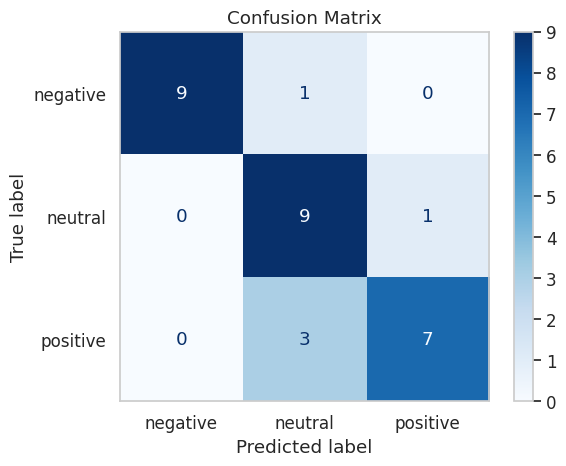

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# labels
label_names = ["negative", "neutral", "positive"]

# compute confusion matrix
cm = confusion_matrix(test_df["labels"], y_pred)

# display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()